In [36]:
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
import numpy as np
import torch
import pandas as pd
import scipy.sparse as sp
import os
import networkx as nx
from typing import Dict, Tuple
import pickle
from os.path import join, dirname, realpath
import csv
import pickle as pkl
import requests
import os
import pdb

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import zipfile
import io
import gdown

"""
NotLoaded: LCC, Filmtrust, Lastfm, UNC, oklahoma
"""


import requests


def feature_norm(self, features):
    min_values = features.min(axis=0)[0]
    max_values = features.max(axis=0)[0]
    return 2 * (features - min_values).div(max_values - min_values) - 1


class Dataset(object):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset") -> None:
        self.adj_ = None
        self.features_ = None
        self.labels_ = None
        self.idx_train_ = None
        self.idx_val_ = None
        self.idx_test_ = None
        self.sens_ = None
        self.sens_idx_ = None
        self.is_normalize = is_normalize

        self.root = root
        if not os.path.exists(self.root):
            os.makedirs(self.root)
        self.path_name = ""

    def download(self, url: str, filename: str):
        r = requests.get(url)
        assert r.status_code == 200
        open(os.path.join(self.root, self.path_name, filename), "wb").write(r.content)

    def download_zip(self, url: str):
        r = requests.get(url)
        assert r.status_code == 200
        foofile = zipfile.ZipFile(io.BytesIO(r.content))
        foofile.extractall(os.path.join(self.root, self.path_name))

    def adj(self, datatype: str = "torch.sparse"):
        # assert str(type(self.adj_)) == "<class 'torch.Tensor'>"
        if self.adj_ is None:
            return self.adj_
        if datatype == "torch.sparse":
            return self.adj_
        elif datatype == "scipy.sparse":
            return sp.coo_matrix(self.adj.to_dense())
        elif datatype == "np.array":
            return self.adj_.to_dense().numpy()
        else:
            raise ValueError(
                "datatype should be torch.sparse, tf.sparse, np.array, or scipy.sparse"
            )

    def features(self, datatype: str = "torch.tensor"):
        if self.is_normalize and self.features_ is not None:
            self.features_ = feature_norm(self, self.features_)

        if self.features is None:
            return self.features_
        if datatype == "torch.tensor":
            return self.features_
        elif datatype == "np.array":
            return self.features_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor, tf.tensor, or np.array")

    def labels(self, datatype: str = "torch.tensor"):
        if self.labels_ is None:
            return self.labels_
        if datatype == "torch.tensor":
            return self.labels_
        elif datatype == "np.array":
            return self.labels_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor, tf.tensor, or np.array")

    def idx_val(self, datatype: str = "torch.tensor"):
        if self.idx_val_ is None:
            return self.idx_val_
        if datatype == "torch.tensor":
            return self.idx_val_
        elif datatype == "np.array":
            return self.idx_val_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor, tf.tensor, or np.array")

    def idx_train(self, datatype: str = "torch.tensor"):
        if self.idx_train_ is None:
            return self.idx_train_
        if datatype == "torch.tensor":
            return self.idx_train_
        elif datatype == "np.array":
            return self.idx_train_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor, tf.tensor, or np.array")

    def idx_test(self, datatype: str = "torch.tensor"):
        if self.idx_test_ is None:
            return self.idx_test_
        if datatype == "torch.tensor":
            return self.idx_test_
        elif datatype == "np.array":
            return self.idx_test_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor, tf.tensor, or np.array")

    def sens(self, datatype: str = "torch.tensor"):
        if self.sens_ is None:
            return self.sens_
        if datatype == "torch.tensor":
            return self.sens_
        elif datatype == "np.array":
            return self.sens_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor, tf.tensor, or np.array")

    def sens_idx(self):
        if self.sens_idx_ is None:
            self.sens_idx_ = -1
        return self.sens_idx_


def mx_to_torch_sparse_tensor(sparse_mx, is_sparse=False, return_tensor_sparse=True):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    if not is_sparse:
        sparse_mx = sp.coo_matrix(sparse_mx)
    else:
        sparse_mx = sparse_mx.tocoo()
    if not return_tensor_sparse:
        return sparse_mx

    sparse_mx = sparse_mx.astype(np.float32)
    indices = torch.from_numpy(
        np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64)
    )
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)


class Google(Dataset):
    def __init__(
        self, is_normalize: bool = False, root: str = "./dataset", sym=True
    ) -> None:
        super().__init__(root=root, is_normalize=is_normalize)
        self.path_name = "google"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))

        id = "111058843129764709244"
        # download if not downloaded locally
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "{}.edges".format(id))
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/gplus/111058843129764709244.edges"
            filename = "{}.edges".format(id)
            self.download(url, filename)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "{}.feat".format(id))
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/gplus/{}.feat".format(
                id
            )
            filename = "{}.feat".format(id)
            self.download(url, filename)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "{}.featnames".format(id))
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/gplus/111058843129764709244.featnames"
            filename = "{}.featnames".format(id)
            self.download(url, filename)

        edges_file = open(
            os.path.join(self.root, self.path_name, "{}.edges".format(id))
        )
        edges = []
        for line in edges_file:
            edges.append([int(one) for one in line.strip("\n").split(" ")])

        feat_file = open(os.path.join(self.root, self.path_name, "{}.feat".format(id)))
        feats = []
        for line in feat_file:
            feats.append([int(one) for one in line.strip("\n").split(" ")])

        feat_name_file = open(
            os.path.join(self.root, self.path_name, "{}.featnames".format(id))
        )
        feat_name = []
        for line in feat_name_file:
            feat_name.append(line.strip("\n").split(" "))
        names = {}
        for name in feat_name:
            if name[1] not in names:
                names[name[1]] = name[1]

        feats = np.array(feats)

        node_mapping = {}
        for j in range(feats.shape[0]):
            node_mapping[feats[j][0]] = j

        feats = feats[:, 1:]

        feats = np.array(feats, dtype=float)

        sens = feats[:, 0]
        labels = feats[:, 164]

        feats = np.concatenate([feats[:, :164], feats[:, 165:]], -1)
        feats = feats[:, 1:]

        edges = np.array(edges)
        # edges=torch.tensor(edges)

        node_num = feats.shape[0]
        adj = np.zeros([node_num, node_num])

        for j in range(edges.shape[0]):
            adj[node_mapping[edges[j][0]], node_mapping[edges[j][1]]] = 1
        if sym:
            for j in range(edges.shape[0]):
                adj[node_mapping[edges[j][1]], node_mapping[edges[j][0]]] = 1

        idx_train = np.random.choice(
            list(range(node_num)), int(0.8 * node_num), replace=False
        )
        idx_val = list(set(list(range(node_num))) - set(idx_train))
        idx_test = np.random.choice(idx_val, len(idx_val) // 2, replace=False)
        idx_val = list(set(idx_val) - set(idx_test))

        self.features_ = torch.FloatTensor(feats)
        self.sens_ = torch.FloatTensor(sens)
        self.idx_train_ = torch.LongTensor(idx_train)
        self.idx_val_ = torch.LongTensor(idx_val)
        self.idx_test_ = torch.LongTensor(idx_test)
        self.labels_ = torch.LongTensor(labels)
        self.features_ = torch.cat([self.features_, self.sens_.unsqueeze(-1)], -1)
        self.sens_idx_ = -1

        self.adj_ = mx_to_torch_sparse_tensor(adj)


class Facebook(Dataset):
    def __init__(
        self,
        path: str = "./dataset/facebook/",
        is_normalize: bool = False,
        root: str = "./dataset",
    ) -> None:
        super().__init__(is_normalize=is_normalize, root=root)
        self.path_name = "facebook"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(os.path.join(self.root, self.path_name, "107.edges")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/facebook/facebook/107.edges"
            filename = "107.edges"
            self.download(url, filename)
        if not os.path.exists(os.path.join(self.root, self.path_name, "107.feat")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/facebook/facebook/107.feat"
            filename = "107.feat"
            self.download(url, filename)
        if not os.path.exists(os.path.join(self.root, self.path_name, "107.featnames")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/facebook/facebook/107.featnames"
            filename = "107.featnames"
            self.download(url, filename)

        edges_file = open(os.path.join(self.root, self.path_name, "107.edges"))
        edges = []
        for line in edges_file:
            edges.append([int(one) for one in line.strip("\n").split(" ")])

        feat_file = open(os.path.join(self.root, self.path_name, "107.feat"))
        feats = []
        for line in feat_file:
            feats.append([int(one) for one in line.strip("\n").split(" ")])

        feat_name_file = open(os.path.join(self.root, self.path_name, "107.featnames"))
        feat_name = []
        for line in feat_name_file:
            feat_name.append(line.strip("\n").split(" "))
        names = {}
        for name in feat_name:
            if name[1] not in names:
                names[name[1]] = name[1]

        feats = np.array(feats)

        node_mapping = {}
        for j in range(feats.shape[0]):
            node_mapping[feats[j][0]] = j

        feats = feats[:, 1:]

        sens = feats[:, 264]
        labels = feats[:, 220]

        feats = np.concatenate([feats[:, :264], feats[:, 266:]], -1)

        feats = np.concatenate([feats[:, :220], feats[:, 221:]], -1)

        edges = np.array(edges)
        # edges=torch.tensor(edges)
        # edges=torch.stack([torch.tensor(one) for one in edges],0)

        node_num = feats.shape[0]
        adj = np.zeros([node_num, node_num])

        for j in range(edges.shape[0]):
            adj[node_mapping[edges[j][0]], node_mapping[edges[j][1]]] = 1

        idx_train = np.random.choice(
            list(range(node_num)), int(0.8 * node_num), replace=False
        )
        idx_val = list(set(list(range(node_num))) - set(idx_train))
        idx_test = np.random.choice(idx_val, len(idx_val) // 2, replace=False)
        idx_val = list(set(idx_val) - set(idx_test))

        self.features_ = torch.FloatTensor(feats)
        self.sens_ = torch.FloatTensor(sens)
        self.idx_train_ = torch.LongTensor(idx_train)
        self.idx_val_ = torch.LongTensor(idx_val)
        self.idx_test_ = torch.LongTensor(idx_test)
        self.labels_ = torch.LongTensor(labels)

        self.features_ = torch.cat([self.features_, self.sens_.unsqueeze(-1)], -1)
        self.adj_ = mx_to_torch_sparse_tensor(adj)
        self.sens_idx_ = -1


class Nba(Dataset):
    def __init__(
        self,
        dataset_name="nba",
        predict_attr_specify=None,
        return_tensor_sparse=True,
        is_normalize: bool = False,
        root: str = "./dataset",
    ):
        super().__init__(is_normalize=is_normalize, root=root)
        if dataset_name != "nba":
            if dataset_name == "pokec_z":
                dataset = "region_job"
            elif dataset_name == "pokec_n":
                dataset = "region_job_2"
            else:
                dataset = None
            sens_attr = "region"
            predict_attr = "I_am_working_in_field"
            label_number = 500
            sens_number = 200
            seed = 20
            path = "./dataset/pokec/"
            test_idx = False
        else:
            dataset = "nba"
            sens_attr = "country"
            predict_attr = "SALARY"
            label_number = 100
            sens_number = 50
            seed = 20
            path = "./dataset/NBA"
            test_idx = True

        (
            adj,
            features,
            labels,
            idx_train,
            idx_val,
            idx_test,
            sens,
            idx_sens_train,
        ) = self.load_pokec(
            dataset,
            sens_attr,
            predict_attr if predict_attr_specify == None else predict_attr_specify,
            path=path,
            label_number=label_number,
            sens_number=sens_number,
            seed=seed,
            test_idx=test_idx,
        )

        # adj=adj.todense()
        adj = mx_to_torch_sparse_tensor(
            adj, is_sparse=True, return_tensor_sparse=return_tensor_sparse
        )
        labels[labels > 1] = 1

        self.adj_ = adj
        self.features_ = features
        self.labels_ = labels
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens
        self.sens_idx_ = -1

    def load_pokec(
        self,
        dataset,
        sens_attr,
        predict_attr,
        path="../dataset/pokec/",
        label_number=1000,
        sens_number=500,
        seed=19,
        test_idx=False,
    ):
        """Load data"""

        self.path_name = "nba"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(os.path.join(self.root, self.path_name, "nba.csv")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/NBA/nba.csv"
            filename = "nba.csv"
            self.download(url, filename)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "nba_relationship.txt")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/NBA/nba_relationship.txt"
            filename = "nba_relationship.txt"
            self.download(url, filename)

        idx_features_labels = pd.read_csv(
            os.path.join(self.root, self.path_name, "nba.csv")
        )
        header = list(idx_features_labels.columns)
        header.remove("user_id")

        header.remove(sens_attr)
        header.remove(predict_attr)

        features = sp.csr_matrix(idx_features_labels[header], dtype=np.float32)
        labels = idx_features_labels[predict_attr].values

        # build graph
        idx = np.array(idx_features_labels["user_id"], dtype=np.int64)
        idx_map = {j: i for i, j in enumerate(idx)}
        edges_unordered = np.genfromtxt(
            os.path.join(self.root, self.path_name, "nba_relationship.txt"),
            dtype=np.int64,
        )

        edges = np.array(
            list(map(idx_map.get, edges_unordered.flatten())), dtype=np.int64
        ).reshape(edges_unordered.shape)

        adj = sp.coo_matrix(
            (np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
            shape=(labels.shape[0], labels.shape[0]),
            dtype=np.float32,
        )
        # build symmetric adjacency matrix
        adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

        # features = normalize(features)
        adj = adj + sp.eye(adj.shape[0])

        features = torch.FloatTensor(np.array(features.todense()))
        labels = torch.LongTensor(labels)
        # adj = mx_to_torch_sparse_tensor(adj)

        import random

        random.seed(seed)
        label_idx = np.where(labels >= 0)[0]
        random.shuffle(label_idx)

        idx_train = label_idx[: min(int(0.5 * len(label_idx)), label_number)]
        idx_val = label_idx[int(0.5 * len(label_idx)) : int(0.75 * len(label_idx))]
        if test_idx:
            idx_test = label_idx[label_number:]
            idx_val = idx_test
        else:
            idx_test = label_idx[int(0.75 * len(label_idx)) :]

        sens = idx_features_labels[sens_attr].values

        sens_idx = set(np.where(sens >= 0)[0])
        idx_test = np.asarray(list(sens_idx & set(idx_test)))
        sens = torch.FloatTensor(sens)
        idx_sens_train = list(sens_idx - set(idx_val) - set(idx_test))
        random.seed(seed)
        random.shuffle(idx_sens_train)
        idx_sens_train = torch.LongTensor(idx_sens_train[:sens_number])

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)

        features = torch.cat([features, sens.unsqueeze(-1)], -1)
        # random.shuffle(sens_idx)

        return adj, features, labels, idx_train, idx_val, idx_test, sens, idx_sens_train


class Pokec_z(Dataset):
    def __init__(
        self,
        dataset_name="pokec_z",
        predict_attr_specify=None,
        return_tensor_sparse=True,
        is_normalize: bool = False,
        root: str = "./dataset",
    ):
        super().__init__(is_normalize=is_normalize, root=root)
        if dataset_name != "nba":
            if dataset_name == "pokec_z":
                dataset = "region_job"
            elif dataset_name == "pokec_n":
                dataset = "region_job_2"
            else:
                dataset = None
            sens_attr = "region"
            predict_attr = "I_am_working_in_field"
            label_number = 500
            sens_number = 200
            seed = 20
            path = "./dataset/pokec/"
            test_idx = False
        else:
            dataset = "nba"
            sens_attr = "country"
            predict_attr = "SALARY"
            label_number = 100
            sens_number = 50
            seed = 20
            path = "./dataset/NBA"
            test_idx = True

        (
            adj,
            features,
            labels,
            idx_train,
            idx_val,
            idx_test,
            sens,
            idx_sens_train,
        ) = self.load_pokec(
            dataset,
            sens_attr,
            predict_attr if predict_attr_specify == None else predict_attr_specify,
            path=path,
            label_number=label_number,
            sens_number=sens_number,
            seed=seed,
            test_idx=test_idx,
        )

        # adj=adj.todense(
        adj = mx_to_torch_sparse_tensor(
            adj, is_sparse=True, return_tensor_sparse=return_tensor_sparse
        )
        labels[labels > 1] = 1
        self.adj_ = adj
        self.features_ = features
        self.labels_ = labels
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens
        self.sens_idx_ = -1

    def load_pokec(
        self,
        dataset,
        sens_attr,
        predict_attr,
        path="../dataset/pokec/",
        label_number=1000,
        sens_number=500,
        seed=19,
        test_idx=False,
    ):
        """Load data"""

        self.path_name = "pokec_z"
        self.url = "https://drive.google.com/u/0/uc?id=1FOYOIdFp6lI9LH5FJAzLhjFCMAxT6wb4&export=download"
        self.destination = os.path.join(self.root, self.path_name, "pokec_z.zip")
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "region_job.csv")
        ):
            gdown.download(self.url, self.destination)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "region_job_relationship.txt")
        ):
            gdown.download(self.url, self.destination, quiet=False)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))

        idx_features_labels = pd.read_csv(
            os.path.join(self.root, self.path_name, "region_job.csv")
        )
        header = list(idx_features_labels.columns)
        header.remove("user_id")

        header.remove(sens_attr)
        header.remove(predict_attr)

        features = sp.csr_matrix(idx_features_labels[header], dtype=np.float32)
        labels = idx_features_labels[predict_attr].values

        # build graph
        idx = np.array(idx_features_labels["user_id"], dtype=np.int64)
        idx_map = {j: i for i, j in enumerate(idx)}
        edges_unordered = np.genfromtxt(
            os.path.join(self.root, self.path_name, "region_job_relationship.txt"),
            dtype=np.int64,
        )

        edges = np.array(
            list(map(idx_map.get, edges_unordered.flatten())), dtype=np.int64
        ).reshape(edges_unordered.shape)

        adj = sp.coo_matrix(
            (np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
            shape=(labels.shape[0], labels.shape[0]),
            dtype=np.float32,
        )
        # build symmetric adjacency matrix
        adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

        # features = normalize(features)
        adj = adj + sp.eye(adj.shape[0])

        features = torch.FloatTensor(np.array(features.todense()))
        labels = torch.LongTensor(labels)
        # adj = mx_to_torch_sparse_tensor(adj)

        import random

        random.seed(seed)
        label_idx = np.where(labels >= 0)[0]
        random.shuffle(label_idx)

        idx_train = label_idx[: min(int(0.5 * len(label_idx)), label_number)]
        idx_val = label_idx[int(0.5 * len(label_idx)) : int(0.75 * len(label_idx))]
        if test_idx:
            idx_test = label_idx[label_number:]
            idx_val = idx_test
        else:
            idx_test = label_idx[int(0.75 * len(label_idx)) :]

        sens = idx_features_labels[sens_attr].values

        sens_idx = set(np.where(sens >= 0)[0])
        idx_test = np.asarray(list(sens_idx & set(idx_test)))
        sens = torch.FloatTensor(sens)
        idx_sens_train = list(sens_idx - set(idx_val) - set(idx_test))
        random.seed(seed)
        random.shuffle(idx_sens_train)
        idx_sens_train = torch.LongTensor(idx_sens_train[:sens_number])

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)

        features = torch.cat([features, sens.unsqueeze(-1)], -1)
        # random.shuffle(sens_idx)

        return adj, features, labels, idx_train, idx_val, idx_test, sens, idx_sens_train


class Pokec_n(Dataset):
    def __init__(
        self,
        dataset_name="pokec_n",
        predict_attr_specify=None,
        return_tensor_sparse=True,
        is_normalize: bool = False,
        root: str = "./dataset",
    ):
        super().__init__(is_normalize=is_normalize, root=root)
        if dataset_name != "nba":
            if dataset_name == "pokec_z":
                dataset = "region_job"
            elif dataset_name == "pokec_n":
                dataset = "region_job_2"
            else:
                dataset = None
            sens_attr = "region"
            predict_attr = "I_am_working_in_field"
            label_number = 500
            sens_number = 200
            seed = 20
            path = "./dataset/pokec/"
            test_idx = False
        else:
            dataset = "nba"
            sens_attr = "country"
            predict_attr = "SALARY"
            label_number = 100
            sens_number = 50
            seed = 20
            path = "./dataset/NBA"
            test_idx = True

        (
            adj,
            features,
            labels,
            idx_train,
            idx_val,
            idx_test,
            sens,
            idx_sens_train,
        ) = self.load_pokec(
            dataset,
            sens_attr,
            predict_attr if predict_attr_specify == None else predict_attr_specify,
            path=path,
            label_number=label_number,
            sens_number=sens_number,
            seed=seed,
            test_idx=test_idx,
        )

        adj = mx_to_torch_sparse_tensor(
            adj, is_sparse=True, return_tensor_sparse=return_tensor_sparse
        )
        labels[labels > 1] = 1
        self.adj_ = adj
        self.features_ = features
        self.labels_ = labels
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens
        self.sens_idx_ = -1

    def load_pokec(
        self,
        dataset,
        sens_attr,
        predict_attr,
        path="../dataset/pokec/",
        label_number=1000,
        sens_number=500,
        seed=19,
        test_idx=False,
    ):
        """Load data"""

        self.path_name = "pokec_n"
        self.url = "https://drive.google.com/u/0/uc?id=1wWm6hyCUjwnr0pWlC6OxZIj0H0ZSnGWs&export=download"
        self.destination = os.path.join(self.root, self.path_name, "pokec_n.zip")
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "region_job_2.csv")
        ):
            gdown.download(self.url, self.destination, quiet=False)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "region_job_2_relationship.txt")
        ):
            gdown.download(self.url, self.destination, quiet=False)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))

        idx_features_labels = pd.read_csv(
            os.path.join(self.root, self.path_name, "region_job_2.csv")
        )
        header = list(idx_features_labels.columns)
        header.remove("user_id")

        header.remove(sens_attr)
        header.remove(predict_attr)

        features = sp.csr_matrix(idx_features_labels[header], dtype=np.float32)
        labels = idx_features_labels[predict_attr].values

        # build graph
        idx = np.array(idx_features_labels["user_id"], dtype=np.int64)
        idx_map = {j: i for i, j in enumerate(idx)}
        edges_unordered = np.genfromtxt(
            os.path.join(self.root, self.path_name, "region_job_2_relationship.txt"),
            dtype=np.int64,
        )

        edges = np.array(
            list(map(idx_map.get, edges_unordered.flatten())), dtype=np.int64
        ).reshape(edges_unordered.shape)

        adj = sp.coo_matrix(
            (np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
            shape=(labels.shape[0], labels.shape[0]),
            dtype=np.float32,
        )
        # build symmetric adjacency matrix
        adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

        # features = normalize(features)
        adj = adj + sp.eye(adj.shape[0])

        features = torch.FloatTensor(np.array(features.todense()))
        labels = torch.LongTensor(labels)
        # adj = mx_to_torch_sparse_tensor(adj)

        import random

        random.seed(seed)
        label_idx = np.where(labels >= 0)[0]
        random.shuffle(label_idx)

        idx_train = label_idx[: min(int(0.5 * len(label_idx)), label_number)]
        idx_val = label_idx[int(0.5 * len(label_idx)) : int(0.75 * len(label_idx))]
        if test_idx:
            idx_test = label_idx[label_number:]
            idx_val = idx_test
        else:
            idx_test = label_idx[int(0.75 * len(label_idx)) :]

        sens = idx_features_labels[sens_attr].values

        sens_idx = set(np.where(sens >= 0)[0])
        idx_test = np.asarray(list(sens_idx & set(idx_test)))
        sens = torch.FloatTensor(sens)
        idx_sens_train = list(sens_idx - set(idx_val) - set(idx_test))
        random.seed(seed)
        random.shuffle(idx_sens_train)
        idx_sens_train = torch.LongTensor(idx_sens_train[:sens_number])

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)

        features = torch.cat([features, sens.unsqueeze(-1)], -1)

        # random.shuffle(sens_idx)

        return adj, features, labels, idx_train, idx_val, idx_test, sens, idx_sens_train


class Twitter(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super().__init__(is_normalize=is_normalize, root=root)
        self.path_name = "twitter"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(os.path.join(self.root, self.path_name, "428333.edges")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/twitter/twitter/428333.edges"
            filename = "428333.edges"
            self.download(url, filename)
        if not os.path.exists(os.path.join(self.root, self.path_name, "428333.feat")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/twitter/twitter/428333.feat"
            filename = "428333.feat"
            self.download(url, filename)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "428333.featnames")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/twitter/twitter/428333.featnames"
            filename = "428333.featnames"
            self.download(url, filename)

        edges_file = open(os.path.join(self.root, self.path_name, "428333.edges"))
        edges = []
        for line in edges_file:
            edges.append([int(one) for one in line.strip("\n").split(" ")])

        feat_file = open(os.path.join(self.root, self.path_name, "428333.feat"))
        feats = []
        for line in feat_file:
            feats.append([int(one) for one in line.strip("\n").split(" ")])

        feat_name_file = open(
            os.path.join(self.root, self.path_name, "428333.featnames")
        )
        feat_name = []
        for line in feat_name_file:
            feat_name.append(line.strip("\n").split(" "))

        names = {}
        for name in feat_name:
            if name[1] not in names:
                names[name[1]] = name[1]

        feats = np.array(feats)

        node_mapping = {}
        for j in range(feats.shape[0]):
            node_mapping[feats[j][0]] = j

        feats = feats[:, 1:]

        sens = feats[:, 264]
        labels = feats[:, 220]

        feats = np.concatenate([feats[:, :264], feats[:, 266:]], -1)

        feats = np.concatenate([feats[:, :220], feats[:, 221:]], -1)
        edges = np.array(edges)
        # edges=torch.tensor(edges)

        # edges=torch.stack([torch.tensor(one) for one in edges],0)

        node_num = feats.shape[0]
        adj = np.zeros([node_num, node_num])

        for j in range(edges.shape[0]):
            adj[node_mapping[edges[j][0]], node_mapping[edges[j][1]]] = 1

        idx_train = np.random.choice(
            list(range(node_num)), int(0.8 * node_num), replace=False
        )
        idx_val = list(set(list(range(node_num))) - set(idx_train))
        idx_test = np.random.choice(idx_val, len(idx_val) // 2, replace=False)
        idx_val = list(set(idx_val) - set(idx_test))

        features = torch.FloatTensor(feats)
        sens = torch.FloatTensor(sens)
        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)
        labels = torch.LongTensor(labels)
        features = torch.cat([features, sens.unsqueeze(-1)], -1)
        adj = mx_to_torch_sparse_tensor(adj)
        self.adj_ = adj
        self.features_ = features
        self.labels_ = labels
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens
        self.sens_idx_ = -1


class Cora(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset") -> None:
        super().__init__(is_normalize=is_normalize, root=root)
        self.cora_label = {
            "Genetic_Algorithms": 0,
            "Reinforcement_Learning": 1,
            "Neural_Networks": 2,
            "Rule_Learning": 3,
            "Case_Based": 4,
            "Theory": 5,
            "Probabilistic_Methods": 6,
        }
        test_ratio = 0.1
        G, adj, features, sensitive, test_edges_true, test_edges_false, _ = self.cora(
            test_ratio=test_ratio
        )

        features = torch.FloatTensor(features)
        sens = torch.FloatTensor(sensitive)
        node_num = features.shape[0]

        idx_train = np.random.choice(
            list(range(node_num)), int(0.8 * node_num), replace=False
        )
        idx_val = list(set(list(range(node_num))) - set(idx_train))
        idx_test = np.random.choice(idx_val, len(idx_val) // 2, replace=False)
        idx_val = list(set(idx_val) - set(idx_test))

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)

        features = torch.cat([features, sens.unsqueeze(-1)], -1)
        adj = mx_to_torch_sparse_tensor(adj)
        self.adj_ = adj
        self.features_ = features
        self.labels_ = sens
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens
        self.sens_idx_ = -1

    def build_test(self, G: nx.Graph, nodelist: Dict, ratio: float) -> Tuple:
        """
        Split training and testing set for link prediction in graph G.
        :param G: nx.Graph
        :param nodelist: idx -> node_id in nx.Graph
        :param ratio: ratio of positive links that used for testing
        :return: Graph that remove all test edges, list of index for test edges
        """

        edges = list(G.edges.data(default=False))
        num_nodes, num_edges = G.number_of_nodes(), G.number_of_edges()
        num_test = int(np.floor(num_edges * ratio))
        test_edges_true = []
        test_edges_false = []

        # generate false links for testing
        while len(test_edges_false) < num_test:
            idx_u = np.random.randint(0, num_nodes - 1)
            idx_v = np.random.randint(idx_u, num_nodes)

            if idx_u == idx_v:
                continue
            if (nodelist[idx_u], nodelist[idx_v]) in G.edges(nodelist[idx_u]):
                continue
            if (idx_u, idx_v) in test_edges_false:
                continue
            else:
                test_edges_false.append((idx_u, idx_v))

        # generate true links for testing
        all_edges_idx = list(range(num_edges))
        np.random.shuffle(all_edges_idx)
        test_edges_true_idx = all_edges_idx[:num_test]
        for test_idx in test_edges_true_idx:
            u, v, _ = edges[test_idx]
            G.remove_edge(u, v)
            test_edges_true.append(
                (self.get_key(nodelist, u), self.get_key(nodelist, v))
            )

        return G, test_edges_true, test_edges_false

    def get_key(self, dict, value):
        return [k for k, v in dict.items() if v == value][0]

    def parse_index_file(self, filename):
        index = []
        for line in open(filename):
            index.append(int(line.strip()))
        return index

    def cora(
        self,
        feat_path="./dataset/cora/cora.content",
        edge_path="./dataset/cora/cora.cites",
        test_ratio=0.1,
    ):
        self.path_name = "cora"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))

        if not os.path.exists(os.path.join(self.root, self.path_name, "cora.content")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/cora/cora.content"
            file_name = "cora.content"
            self.download(url, file_name)
        if not os.path.exists(os.path.join(self.root, self.path_name, "cora.cites")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/cora/cora.cites"
            file_name = "cora.cites"
            self.download(url, file_name)
        idx_features_labels = np.genfromtxt(
            os.path.join(self.root, self.path_name, "cora.content"), dtype=np.dtype(str)
        )
        idx_features_labels = idx_features_labels[
            idx_features_labels[:, 0].astype(np.int32).argsort()
        ]

        idx = np.array(idx_features_labels[:, 0], dtype=np.int32)
        nodelist = {idx: node for idx, node in enumerate(idx)}
        X = np.array(idx_features_labels[:, 1:-1], dtype=np.float32)
        sensitive = np.array(list(map(self.cora_label.get, idx_features_labels[:, -1])))

        G = nx.read_edgelist(
            os.path.join(self.root, self.path_name, "cora.cites"), nodetype=int
        )
        G, test_edges_true, test_edges_false = self.build_test(G, nodelist, test_ratio)
        for edge in G.edges():
            G[edge[0]][edge[1]]["weight"] = 1
        adj = nx.adjacency_matrix(G, nodelist=sorted(G.nodes()))

        return G, adj, X, sensitive, test_edges_true, test_edges_false, nodelist


class Citeseer(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset") -> None:
        super().__init__(is_normalize=is_normalize, root=root)
        self.cora_label = {
            "Genetic_Algorithms": 0,
            "Reinforcement_Learning": 1,
            "Neural_Networks": 2,
            "Rule_Learning": 3,
            "Case_Based": 4,
            "Theory": 5,
            "Probabilistic_Methods": 6,
        }
        test_ratio = 0.1

        (
            G,
            adj,
            features,
            sensitive,
            test_edges_true,
            test_edges_false,
            _,
        ) = self.citeseer(test_ratio=test_ratio)

        node_num = features.shape[0]

        features = torch.FloatTensor(features)
        sens = torch.FloatTensor(sensitive)

        idx_train = np.random.choice(
            list(range(node_num)), int(0.8 * node_num), replace=False
        )
        idx_val = list(set(list(range(node_num))) - set(idx_train))
        idx_test = np.random.choice(idx_val, len(idx_val) // 2, replace=False)
        idx_val = list(set(idx_val) - set(idx_test))

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)

        features = torch.cat([features, sens.unsqueeze(-1)], -1)
        adj = mx_to_torch_sparse_tensor(adj)
        self.adj_ = adj
        self.features_ = features
        self.labels_ = sens
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens
        self.sens_idx_ = -1

    def build_test(self, G: nx.Graph, nodelist: Dict, ratio: float) -> Tuple:
        """
        Split training and testing set for link prediction in graph G.
        :param G: nx.Graph
        :param nodelist: idx -> node_id in nx.Graph
        :param ratio: ratio of positive links that used for testing
        :return: Graph that remove all test edges, list of index for test edges
        """

        edges = list(G.edges.data(default=False))
        num_nodes, num_edges = G.number_of_nodes(), G.number_of_edges()
        num_test = int(np.floor(num_edges * ratio))
        test_edges_true = []
        test_edges_false = []

        # generate false links for testing
        while len(test_edges_false) < num_test:
            idx_u = np.random.randint(0, num_nodes - 1)
            idx_v = np.random.randint(idx_u, num_nodes)

            if idx_u == idx_v:
                continue
            if (nodelist[idx_u], nodelist[idx_v]) in G.edges(nodelist[idx_u]):
                continue
            if (idx_u, idx_v) in test_edges_false:
                continue
            else:
                test_edges_false.append((idx_u, idx_v))

        # generate true links for testing
        all_edges_idx = list(range(num_edges))
        np.random.shuffle(all_edges_idx)
        test_edges_true_idx = all_edges_idx[:num_test]
        for test_idx in test_edges_true_idx:
            u, v, _ = edges[test_idx]
            G.remove_edge(u, v)
            test_edges_true.append(
                (self.get_key(nodelist, u), self.get_key(nodelist, v))
            )

        return G, test_edges_true, test_edges_false

    def get_key(self, dict, value):
        return [k for k, v in dict.items() if v == value][0]

    def parse_index_file(self, filename):
        index = []
        for line in open(filename):
            index.append(int(line.strip()))
        return index

    def citeseer(self, data_dir="./dataset/citeseer", test_ratio=0.1):
        names = ["x", "y", "tx", "ty", "allx", "ally", "graph", "test.index"]
        objects = []
        self.path_name = "citeseer"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))

        for i in range(len(names)):
            if not os.path.exists(
                os.path.join(
                    self.root, self.path_name, "ind.citeseer.{}".format(names[i])
                )
            ):
                url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/citeseer/ind.citeseer.{}".format(
                    names[i]
                )
                file_name = "ind.citeseer.{}".format(names[i])
                self.download(url, file_name)

        for i in range(len(names) - 1):
            with open(
                os.path.join(
                    self.root, self.path_name, "ind.citeseer.{}".format(names[i])
                ),
                "rb",
            ) as rf:
                u = pkl._Unpickler(rf)
                u.encoding = "latin1"
                cur_data = u.load()
                objects.append(cur_data)

        x, y, tx, ty, allx, ally, graph = tuple(objects)
        X = sp.vstack((allx, tx)).toarray()
        sensitive = sp.vstack((ally, ty))
        sensitive = np.where(sensitive.toarray() == 1)[1]

        G = nx.from_dict_of_lists(graph)
        test_idx_reorder = self.parse_index_file(
            os.path.join(self.root, self.path_name, "ind.citeseer.test.index")
        )
        test_idx_range = np.sort(test_idx_reorder)

        missing_idx = set(range(min(test_idx_range), max(test_idx_range) + 1)) - set(
            test_idx_range
        )
        for idx in missing_idx:
            G.remove_node(idx)

        nodes = sorted(G.nodes())
        nodelist = {
            idx: node for idx, node in zip(range(G.number_of_nodes()), list(nodes))
        }

        G, test_edges_true, test_edges_false = self.build_test(G, nodelist, test_ratio)
        for edge in G.edges():
            G[edge[0]][edge[1]]["weight"] = 1

        adj = nx.adjacency_matrix(G, nodelist=nodes)

        return G, adj, X, sensitive, test_edges_true, test_edges_false, nodelist


class German(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(German, self).__init__(is_normalize=is_normalize, root=root)
        (
            adj,
            features,
            labels,
            edges,
            sens,
            idx_train,
            idx_val,
            idx_test,
            sens_idx,
        ) = self.load_german("german")

        node_num = features.shape[0]

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)
        labels = torch.LongTensor(labels)

        adj = mx_to_torch_sparse_tensor(adj, is_sparse=True)
        self.adj_ = adj
        self.features_ = features
        self.labels_ = labels
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens
        self.sens_idx_ = sens_idx

    def feature_norm(self, features):
        min_values = features.min(axis=0)[0]
        max_values = features.max(axis=0)[0]
        return 2 * (features - min_values).div(max_values - min_values) - 1

    def load_german(
        self,
        dataset,
        sens_attr="Gender",
        predict_attr="GoodCustomer",
        path="./dataset/german/",
        label_number=100,
    ):
        # print('Loading {} dataset from {}'.format(dataset, path))
        self.path_name = "german"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))

        if not os.path.exists(os.path.join(self.root, self.path_name, "german.csv")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/german/german.csv"
            file_name = "german.csv"
            self.download(url, file_name)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "german_edges.txt")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/german/german_edges.txt"
            file_name = "german_edges.txt"
            self.download(url, file_name)

        idx_features_labels = pd.read_csv(
            os.path.join(self.root, self.path_name, "{}.csv".format(dataset))
        )
        header = list(idx_features_labels.columns)
        header.remove(predict_attr)
        header.remove("OtherLoansAtStore")
        header.remove("PurposeOfLoan")

        # Sensitive Attribute
        idx_features_labels["Gender"][idx_features_labels["Gender"] == "Female"] = 1
        idx_features_labels["Gender"][idx_features_labels["Gender"] == "Male"] = 0

        edges_unordered = np.genfromtxt(
            os.path.join(self.root, self.path_name, f"{dataset}_edges.txt")
        ).astype("int")

        features = sp.csr_matrix(idx_features_labels[header], dtype=np.float32)
        labels = idx_features_labels[predict_attr].values
        labels[labels == -1] = 0

        idx = np.arange(features.shape[0])
        idx_map = {j: i for i, j in enumerate(idx)}
        edges = np.array(
            list(map(idx_map.get, edges_unordered.flatten())), dtype=int
        ).reshape(edges_unordered.shape)

        adj = sp.coo_matrix(
            (np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
            shape=(labels.shape[0], labels.shape[0]),
            dtype=np.float32,
        )
        # build symmetric adjacency matrix
        adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

        adj = adj + sp.eye(adj.shape[0])

        features = torch.FloatTensor(np.array(features.todense()))

        labels = torch.LongTensor(labels)

        import random

        random.seed(20)
        label_idx_0 = np.where(labels == 0)[0]
        label_idx_1 = np.where(labels == 1)[0]
        random.shuffle(label_idx_0)
        random.shuffle(label_idx_1)

        idx_train = np.append(
            label_idx_0[: min(int(0.5 * len(label_idx_0)), label_number // 2)],
            label_idx_1[: min(int(0.5 * len(label_idx_1)), label_number // 2)],
        )
        idx_val = np.append(
            label_idx_0[int(0.5 * len(label_idx_0)) : int(0.75 * len(label_idx_0))],
            label_idx_1[int(0.5 * len(label_idx_1)) : int(0.75 * len(label_idx_1))],
        )
        idx_test = np.append(
            label_idx_0[int(0.75 * len(label_idx_0)) :],
            label_idx_1[int(0.75 * len(label_idx_1)) :],
        )

        sens = idx_features_labels[sens_attr].values.astype(int)
        sens = torch.FloatTensor(sens)
        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)

        return adj, features, labels, edges, sens, idx_train, idx_val, idx_test, 0


class Bail(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Bail, self).__init__(is_normalize=is_normalize, root=root)
        (
            adj,
            features,
            labels,
            edges,
            sens,
            idx_train,
            idx_val,
            idx_test,
            sens_idx,
        ) = self.load_bail("bail")

        node_num = features.shape[0]

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)
        labels = torch.LongTensor(labels)
        adj = mx_to_torch_sparse_tensor(adj, is_sparse=True)
        self.adj_ = adj
        self.features_ = features
        self.labels_ = labels
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens
        self.sens_idx_ = sens_idx

    def feature_norm(self, features):
        min_values = features.min(axis=0)[0]
        max_values = features.max(axis=0)[0]
        return 2 * (features - min_values).div(max_values - min_values) - 1

    def load_bail(
        self,
        dataset,
        sens_attr="WHITE",
        predict_attr="RECID",
        path="./dataset/bail/",
        label_number=100,
    ):
        # print('Loading {} dataset from {}'.format(dataset, path))
        self.path_name = "bail"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))

        if not os.path.exists(os.path.join(self.root, self.path_name, "bail.csv")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/bail/bail.csv"
            file_name = "bail.csv"
            self.download(url, file_name)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "bail_edges.txt")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/bail/bail_edges.txt"
            file_name = "bail_edges.txt"
            self.download(url, file_name)

        idx_features_labels = pd.read_csv(
            os.path.join(self.root, self.path_name, "{}.csv".format(dataset))
        )
        header = list(idx_features_labels.columns)
        header.remove(predict_attr)

        # build relationship

        edges_unordered = np.genfromtxt(
            os.path.join(self.root, self.path_name, f"{dataset}_edges.txt")
        ).astype("int")

        features = sp.csr_matrix(idx_features_labels[header], dtype=np.float32)
        labels = idx_features_labels[predict_attr].values

        idx = np.arange(features.shape[0])
        idx_map = {j: i for i, j in enumerate(idx)}
        edges = np.array(
            list(map(idx_map.get, edges_unordered.flatten())), dtype=int
        ).reshape(edges_unordered.shape)

        adj = sp.coo_matrix(
            (np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
            shape=(labels.shape[0], labels.shape[0]),
            dtype=np.float32,
        )

        # build symmetric adjacency matrix
        adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

        # features = normalize(features)
        adj = adj + sp.eye(adj.shape[0])

        features = torch.FloatTensor(np.array(features.todense()))
        labels = torch.LongTensor(labels)

        import random

        random.seed(20)
        label_idx_0 = np.where(labels == 0)[0]
        label_idx_1 = np.where(labels == 1)[0]
        random.shuffle(label_idx_0)
        random.shuffle(label_idx_1)
        idx_train = np.append(
            label_idx_0[: min(int(0.5 * len(label_idx_0)), label_number // 2)],
            label_idx_1[: min(int(0.5 * len(label_idx_1)), label_number // 2)],
        )
        idx_val = np.append(
            label_idx_0[int(0.5 * len(label_idx_0)) : int(0.75 * len(label_idx_0))],
            label_idx_1[int(0.5 * len(label_idx_1)) : int(0.75 * len(label_idx_1))],
        )
        idx_test = np.append(
            label_idx_0[int(0.75 * len(label_idx_0)) :],
            label_idx_1[int(0.75 * len(label_idx_1)) :],
        )

        sens = idx_features_labels[sens_attr].values.astype(int)
        sens = torch.FloatTensor(sens)
        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)

        return adj, features, labels, edges, sens, idx_train, idx_val, idx_test, 0


class Credit(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Credit, self).__init__(is_normalize=is_normalize, root=root)
        (
            adj,
            features,
            labels,
            edges,
            sens,
            idx_train,
            idx_val,
            idx_test,
            sens_idx,
        ) = self.load_credit("credit")

        node_num = features.shape[0]

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)
        labels = torch.LongTensor(labels)
        adj = mx_to_torch_sparse_tensor(adj, is_sparse=True)
        self.adj_ = adj
        self.features_ = features
        self.labels_ = labels
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens
        self.sens_idx_ = sens_idx

    def feature_norm(self, features):
        min_values = features.min(axis=0)[0]
        max_values = features.max(axis=0)[0]
        return 2 * (features - min_values).div(max_values - min_values) - 1

    def load_credit(
        self,
        dataset,
        sens_attr="Age",
        predict_attr="NoDefaultNextMonth",
        path="./dataset/credit/",
        label_number=6000,
    ):
        from scipy.spatial import distance_matrix

        # print('Loading {} dataset from {}'.format(dataset, path))
        self.path_name = "credit"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))

        if not os.path.exists(os.path.join(self.root, self.path_name, "credit.csv")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/credit/credit.csv"
            file_name = "credit.csv"
            self.download(url, file_name)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "credit_edges.txt")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/credit/credit_edges.txt"
            file_name = "credit_edges.txt"
            self.download(url, file_name)

        idx_features_labels = pd.read_csv(
            os.path.join(self.root, self.path_name, "{}.csv".format(dataset))
        )
        header = list(idx_features_labels.columns)
        header.remove(predict_attr)
        header.remove("Single")

        # build relationship
        edges_unordered = np.genfromtxt(
            os.path.join(self.root, self.path_name, f"{dataset}_edges.txt")
        ).astype("int")

        features = sp.csr_matrix(idx_features_labels[header], dtype=np.float32)
        labels = idx_features_labels[predict_attr].values
        idx = np.arange(features.shape[0])
        idx_map = {j: i for i, j in enumerate(idx)}
        edges = np.array(
            list(map(idx_map.get, edges_unordered.flatten())), dtype=int
        ).reshape(edges_unordered.shape)

        adj = sp.coo_matrix(
            (np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
            shape=(labels.shape[0], labels.shape[0]),
            dtype=np.float32,
        )

        # build symmetric adjacency matrix
        adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)
        adj = adj + sp.eye(adj.shape[0])

        features = torch.FloatTensor(np.array(features.todense()))
        labels = torch.LongTensor(labels)

        import random

        random.seed(20)
        label_idx_0 = np.where(labels == 0)[0]
        label_idx_1 = np.where(labels == 1)[0]
        random.shuffle(label_idx_0)
        random.shuffle(label_idx_1)

        idx_train = np.append(
            label_idx_0[: min(int(0.5 * len(label_idx_0)), label_number // 2)],
            label_idx_1[: min(int(0.5 * len(label_idx_1)), label_number // 2)],
        )
        idx_val = np.append(
            label_idx_0[int(0.5 * len(label_idx_0)) : int(0.75 * len(label_idx_0))],
            label_idx_1[int(0.5 * len(label_idx_1)) : int(0.75 * len(label_idx_1))],
        )
        idx_test = np.append(
            label_idx_0[int(0.75 * len(label_idx_0)) :],
            label_idx_1[int(0.75 * len(label_idx_1)) :],
        )

        sens = idx_features_labels[sens_attr].values.astype(int)
        sens = torch.FloatTensor(sens)
        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)

        return adj, features, labels, edges, sens, idx_train, idx_val, idx_test, 1


class LCC(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(LCC, self).__init__(is_normalize=is_normalize, root=root)
        path = "./dataset/raw_LCC"
        name = "LCC"
        self.path_name = "LCC"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        self.url = "https://drive.google.com/u/0/uc?id=1wYb0wP8XgWsAhGPt_o3fpMZDM-yIATFQ&export=download"
        self.destination = os.path.join(self.root, self.path_name, "raw_LCC.zip")
        if not os.path.exists(
            os.path.join(
                self.root, self.path_name, "raw_LCC/edgelist_{}.txt".format(name)
            )
        ):
            gdown.download(self.url, self.destination, quiet=False)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(
                self.root, self.path_name, "raw_LCC/labels_{}.txt".format(name)
            )
        ):
            gdown.download(self.url, self.destination, quiet=False)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "raw_LCC/sens_{}.txt".format(name))
        ):
            gdown.download(self.url, self.destination, quiet=False)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "raw_LCC/X_{}.npz".format(name))
        ):
            gdown.download(self.url, self.destination, quiet=False)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))

        edgelist = csv.reader(
            open(
                os.path.join(
                    self.root, self.path_name, "raw_LCC/edgelist_{}.txt".format(name)
                )
            )
        )

        edges = []
        for line in edgelist:
            edge = line[0].split("\t")
            edges.append([int(one) for one in edge])

        edges = np.array(edges)

        labels_file = csv.reader(
            open(
                os.path.join(
                    self.root, self.path_name, "raw_LCC/labels_{}.txt".format(name)
                )
            )
        )
        labels = []
        for line in labels_file:
            labels.append(float(line[0].split("\t")[1]))
        labels = np.array(labels)

        sens_file = csv.reader(
            open(
                os.path.join(
                    self.root, self.path_name, "raw_LCC/sens_{}.txt".format(name)
                )
            )
        )
        sens = []
        for line in sens_file:
            sens.append([float(line[0].split("\t")[1])])
        sens = np.array(sens)

        adj = sp.coo_matrix(
            (np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
            shape=(labels.shape[0], labels.shape[0]),
            dtype=np.float32,
        )
        # build symmetric adjacency matrix
        adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

        # features = normalize(features)
        adj = adj + sp.eye(adj.shape[0])

        node_num = labels.shape[0]
        # adj=adj.todense()
        idx_train = np.random.choice(
            list(range(node_num)), int(0.8 * node_num), replace=False
        )
        idx_val = list(set(list(range(node_num))) - set(idx_train))
        idx_test = np.random.choice(idx_val, len(idx_val) // 2, replace=False)
        idx_val = list(set(idx_val) - set(idx_test))

        unique_labels, counts = np.unique(labels, return_counts=True)
        most_common_label = unique_labels[np.argmax(counts)]
        labels = (labels == most_common_label).astype(int)

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)
        labels = torch.LongTensor(labels)
        sens = torch.FloatTensor(sens)
        features = np.load(
            os.path.join(self.root, self.path_name, "raw_LCC/X_{}.npz".format(name))
        )

        features = torch.FloatTensor(
            sp.coo_matrix(
                (features["data"], (features["row"], features["col"])),
                shape=(labels.shape[0], np.max(features["col"]) + 1),
                dtype=np.float32,
            ).todense()
        )
        features = torch.cat([features, sens], -1)
        sens = sens.squeeze()

        adj = mx_to_torch_sparse_tensor(adj, is_sparse=True)
        self.adj_ = adj
        self.features_ = features
        self.labels_ = labels
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens


class LCC_small(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(LCC_small, self).__init__(is_normalize=is_normalize, root=root)
        path = "./dataset/raw_small"
        name = "Small"
        self.path_name = "raw_small"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "edgelist_{}.txt".format(name))
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/raw_Small/edgelist_Small.txt"
            file_name = "edgelist_{}.txt".format(name)
            self.download(url, file_name)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "labels_{}.txt".format(name))
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/raw_Small/labels_Small.txt"
            file_name = "labels_{}.txt".format(name)
            self.download(url, file_name)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "sens_{}.txt".format(name))
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/raw_Small/sens_Small.txt"
            file_name = "sens_{}.txt".format(name)
            self.download(url, file_name)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "features_{}.txt".format(name))
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/raw_Small/X_Small.npz"
            file_name = "X_{}.npz".format(name)
            self.download(url, file_name)

        edgelist = csv.reader(
            open(
                os.path.join(self.root, self.path_name, "edgelist_{}.txt".format(name))
            )
        )

        edges = []
        for line in edgelist:
            edge = line[0].split("\t")
            edges.append([int(one) for one in edge])

        edges = np.array(edges)

        labels_file = csv.reader(
            open(os.path.join(self.root, self.path_name, "labels_{}.txt".format(name)))
        )
        labels = []
        for line in labels_file:
            labels.append(float(line[0].split("\t")[1]))
        labels = np.array(labels)

        sens_file = csv.reader(
            open(os.path.join(self.root, self.path_name, "sens_{}.txt".format(name)))
        )
        sens = []
        for line in sens_file:
            sens.append([float(line[0].split("\t")[1])])
        sens = np.array(sens)

        adj = sp.coo_matrix(
            (np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
            shape=(labels.shape[0], labels.shape[0]),
            dtype=np.float32,
        )
        # build symmetric adjacency matrix
        adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

        # features = normalize(features)
        adj = adj + sp.eye(adj.shape[0])

        node_num = labels.shape[0]
        # adj=adj.todense()
        idx_train = np.random.choice(
            list(range(node_num)), int(0.8 * node_num), replace=False
        )
        idx_val = list(set(list(range(node_num))) - set(idx_train))
        idx_test = np.random.choice(idx_val, len(idx_val) // 2, replace=False)
        idx_val = list(set(idx_val) - set(idx_test))

        unique_labels, counts = np.unique(labels, return_counts=True)
        most_common_label = unique_labels[np.argmax(counts)]
        labels = (labels == most_common_label).astype(int)

        idx_train = torch.LongTensor(idx_train)
        idx_val = torch.LongTensor(idx_val)
        idx_test = torch.LongTensor(idx_test)
        labels = torch.LongTensor(labels)
        sens = torch.FloatTensor(sens)
        features = np.load(
            os.path.join(self.root, self.path_name, "X_{}.npz".format(name))
        )

        features = torch.FloatTensor(
            sp.coo_matrix(
                (features["data"], (features["row"], features["col"])),
                shape=(labels.shape[0], np.max(features["col"]) + 1),
                dtype=np.float32,
            ).todense()
        )
        features = torch.cat([features, sens], -1)
        sens = sens.squeeze()
        adj = mx_to_torch_sparse_tensor(adj, is_sparse=True)
        self.adj_ = adj
        self.features_ = features
        self.labels_ = labels
        self.idx_train_ = idx_train
        self.idx_val_ = idx_val
        self.idx_test_ = idx_test
        self.sens_ = sens


class Amazon(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Amazon, self).__init__(is_normalize=is_normalize, root=root)
        dataname = "Amazon-2"
        self.path_name = "amazon"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "training_df.pkl")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/Amazon-2/training_df.pkl"
            file_name = "training_df.pkl"
            self.download(url, file_name)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "valiing_df.pkl")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/Amazon-2/valiing_df.pkl"
            file_name = "valiing_df.pkl"
            self.download(url, file_name)
        if not os.path.exists(os.path.join(self.root, self.path_name, "key_genre.pkl")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/Amazon-2/key_genre.pkl"
            file_name = "key_genre.pkl"
            self.download(url, file_name)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "item_idd_genre_list.pkl")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/Amazon-2/item_idd_genre_list.pkl"
            file_name = "item_idd_genre_list.pkl"
            self.download(url, file_name)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "genre_count.pkl")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/Amazon-2/genre_count.pkl"
            file_name = "genre_count.pkl"
            self.download(url, file_name)

        train_df = pkl.load(
            open(os.path.join(self.root, self.path_name, "training_df.pkl"), "rb")
        )
        vali_df = pkl.load(
            open(os.path.join(self.root, self.path_name, "valiing_df.pkl"), "rb")
        )  # for validation
        # vali_df = pkl.load(open('./' + dataname + '/testing_df.pkl'))  # for testing
        key_genre = pkl.load(
            open(os.path.join(self.root, self.path_name, "key_genre.pkl"), "rb")
        )
        item_idd_genre_list = pkl.load(
            open(
                os.path.join(self.root, self.path_name, "item_idd_genre_list.pkl"), "rb"
            )
        )
        # genre_item_vector = pkl.load(open('./' + dataname + '/genre_item_vector.pkl','rb'))
        genre_count = pkl.load(
            open(os.path.join(self.root, self.path_name, "genre_count.pkl"), "rb")
        )
        # user_genre_count = pkl.load(open('./' + dataname + '/user_genre_count.pkl','rb'))

        num_item = len(train_df["item_id"].unique())
        num_user = len(train_df["user_id"].unique())
        num_genre = len(key_genre)

        item_genre_list = []
        for u in range(num_item):
            gl = item_idd_genre_list[u]
            tmp = []
            for g in gl:
                if g in key_genre:
                    tmp.append(g)
            item_genre_list.append(tmp)

        # genreate item_genre matrix
        item_genre = np.zeros((num_item, num_genre))
        for i in range(num_item):
            gl = item_genre_list[i]
            for k in range(num_genre):
                if key_genre[k] in gl:
                    item_genre[i, k] = 1.0

        genre_count_mean_reciprocal = []
        for k in key_genre:
            genre_count_mean_reciprocal.append(1.0 / genre_count[k])
        genre_count_mean_reciprocal = (np.array(genre_count_mean_reciprocal)).reshape(
            (num_genre, 1)
        )
        genre_error_weight = np.dot(item_genre, genre_count_mean_reciprocal)

        self.item_genre_ = item_genre
        self.genre_error_weight_ = genre_error_weight

    def item_genre(self, datatype: str = "np.array"):
        if self.item_genre_ is None:
            return self.item_genre_
        if datatype == "np.array":
            return self.item_genre_
        elif datatype == "torch.tensor":
            return torch.tensor(self.item_genre_)
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def genre_error_weight(self, datatype: str = "np.array"):
        if self.genre_error_weight_ is None:
            return self.genre_error_weight_
        if datatype == "np.array":
            return self.genre_error_weight_
        elif datatype == "torch.tensor":
            return torch.tensor(self.genre_error_weight_)
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class Yelp(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Yelp, self).__init__(is_normalize=is_normalize, root=root)
        dataname = "Yelp"

        self.path_name = "yelp"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "Yelp/training_df.pkl")
        ):
            url = "https://drive.google.com/u/0/uc?id=1H0gfETzTNG9rWpSOR4wg2hctcIEJHrz1&export=download"
            self.download_zip(url)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "Yelp/valiing_df.pkl")
        ):
            url = "https://drive.google.com/u/0/uc?id=1H0gfETzTNG9rWpSOR4wg2hctcIEJHrz1&export=download"
            self.download_zip(url)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "Yelp/key_genre.pkl")
        ):
            url = "https://drive.google.com/file/d/1H0gfETzTNG9rWpSOR4wg2hctcIEJHrz1/view?usp=sharing/training_df.pk"
            self.download(url, "training_df.pk")
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "Yelp/item_idd_genre_list.pkl")
        ):
            url = "https://drive.google.com/u/0/uc?id=1H0gfETzTNG9rWpSOR4wg2hctcIEJHrz1&export=download"
            self.download_zip(url)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "Yelp/genre_count.pkl")
        ):
            url = "https://drive.google.com/u/0/uc?id=1H0gfETzTNG9rWpSOR4wg2hctcIEJHrz1&export=download"
            self.download_zip(url)

        train_df = pkl.load(
            open(os.path.join(self.root, self.path_name, "Yelp/training_df.pkl"), "rb")
        )
        vali_df = pkl.load(
            open(os.path.join(self.root, self.path_name, "Yelp/valiing_df.pkl"), "rb")
        )  # for validation
        # vali_df = pkl.load(open('./' + dataname + '/testing_df.pkl'))  # for testing
        key_genre = pkl.load(
            open(os.path.join(self.root, self.path_name, "Yelp/key_genre.pkl"), "rb")
        )
        item_idd_genre_list = pkl.load(
            open(
                os.path.join(self.root, self.path_name, "Yelp/item_idd_genre_list.pkl"),
                "rb",
            )
        )
        # genre_item_vector = pkl.load(open('./' + dataname + '/genre_item_vector.pkl','rb'))
        genre_count = pkl.load(
            open(os.path.join(self.root, self.path_name, "Yelp/genre_count.pkl"), "rb")
        )
        # user_genre_count = pkl.load(open('./' + dataname + '/user_genre_count.pkl','rb'))

        num_item = len(train_df["item_id"].unique())
        num_user = len(train_df["user_id"].unique())
        num_genre = len(key_genre)

        item_genre_list = []
        for u in range(num_item):
            gl = item_idd_genre_list[u]
            tmp = []
            for g in gl:
                if g in key_genre:
                    tmp.append(g)
            item_genre_list.append(tmp)

        # genreate item_genre matrix
        item_genre = np.zeros((num_item, num_genre))
        for i in range(num_item):
            gl = item_genre_list[i]
            for k in range(num_genre):
                if key_genre[k] in gl:
                    item_genre[i, k] = 1.0

        genre_count_mean_reciprocal = []
        for k in key_genre:
            genre_count_mean_reciprocal.append(1.0 / genre_count[k])
        genre_count_mean_reciprocal = (np.array(genre_count_mean_reciprocal)).reshape(
            (num_genre, 1)
        )
        genre_error_weight = np.dot(item_genre, genre_count_mean_reciprocal)

        self.item_genre_ = item_genre
        self.genre_error_weight_ = genre_error_weight

    def item_genre(self, datatype: str = "np.array"):
        if self.item_genre_ is None:
            return self.item_genre_
        if datatype == "np.array":
            return self.item_genre_
        elif datatype == "torch.tensor":
            return torch.tensor(self.item_genre_)
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def genre_error_weight(self, datatype: str = "np.array"):
        if self.genre_error_weight_ is None:
            return self.genre_error_weight_
        if datatype == "np.array":
            return self.genre_error_weight_
        elif datatype == "torch.tensor":
            return torch.tensor(self.genre_error_weight_)
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


from scipy.io import loadmat


class data_handler:
    def __init__(
        self,
        rating_path,
        trust_path,
        dataset_name,
    ):
        self.rating_path = rating_path
        self.trust_path = trust_path
        self.n_users = 0
        self.n_prod = 0
        self.n_cat = 6
        self.dataset_name = dataset_name

    def load_matrices(self):
        # Loading Matrices from data
        f1 = open(self.rating_path, "rb")
        f2 = open(self.trust_path, "rb")
        R = loadmat(f1)
        W = loadmat(f2)
        # Converting R and W from dictionary to array
        if self.dataset_name == "epinion":
            R = R["rating_with_timestamp"]
        elif self.dataset_name == "ciao":
            R = R["rating"]
        # print R
        R_old = np.asarray([row for row in R if row[0] < 1000 and row[1] < 1000])
        # R = R['rating']
        W = W["trust"]
        # print W
        W_old = np.asarray([row for row in W if row[0] < 1000 and row[1] < 1000])
        # print W

        self.n_users = 1000
        self.n_prod = 1000

        self.n_users = max(R[:, 0])
        self.n_prod = max(R[:, 1])

        # print self.n_users
        # print self.n_prod
        # Selecting entries with the 6 categories given in the paper
        cat_id = [7, 8, 9, 10, 11, 19]
        cat_map = {7: 0, 8: 1, 9: 2, 10: 3, 11: 4, 19: 5}
        # cat_id = [8, 14, 17, 19, 23, 24]
        # cat_map = {8:0, 14:1, 17:2, 19:3, 23:4, 24:5}
        R = R[np.in1d(R[:, 2], cat_id)]
        R = R[R[:, 5].argsort()]
        R_size = R.shape[0]
        # Choosing 70% data for training and rest for testing
        R_train = R[: R_size * 7 // 10]
        R_test = R[R_size * 7 // 10 :]
        # Making all eligible Product-Category pairs
        # print (R_train.shape[0])
        ones = np.ones(R_train.shape[0])
        prod_cat = dict(zip(zip(R_train[:, 1], R_train[:, 2]), ones))
        prod_cat_old = {}

        # Making the mu matrix
        mu = np.zeros(6)
        for cat in cat_id:
            cat_rating = R_train[np.where(R_train[:, 2] == cat), 3]
            mu[cat_map[cat]] = np.mean(cat_rating)

        return R_train, R_test, W, prod_cat, mu

    def get_stats(self):
        return self.n_users, self.n_prod, self.n_cat


class Epinion(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Epinion, self).__init__(is_normalize=is_normalize, root=root)
        self.path_name = "epinion"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "rating_with_timestamp.mat")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/Epinion%26Ciao/rating_with_timestamp.mat"
            file_name = "rating_with_timestamp.mat"
            self.download(url, file_name)
        if not os.path.exists(os.path.join(self.root, self.path_name, "trust.mat")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/Epinion%26Ciao/trust.mat"
            file_name = "trust.mat"
            self.download(url, file_name)

        rating_path = os.path.join(
            self.root, self.path_name, "rating_with_timestamp.mat"
        )
        trust_path = os.path.join(self.root, self.path_name, "trust.mat")

        data = data_handler(rating_path, trust_path, "epinion")

        R_train, R_test, W, PF_pair, mu = data.load_matrices()
        self.R_train_ = R_train
        self.R_test_ = R_test
        self.W_ = W.astype("uint8")
        self.PF_pair_ = PF_pair
        self.mu_ = mu

        self.R_train_ = torch.tensor(self.R_train_)
        self.R_test_ = torch.tensor(self.R_test_)
        self.W_ = torch.tensor(self.W_)
        self.PF_pair_ = self.PF_pair_
        self.mu_ = torch.tensor(self.mu_)

    def R_train(self, datatype: str = "torch.tensor"):
        if self.R_train_ is None:
            return self.R_train_
        if datatype == "torch.tensor":
            return self.R_train_
        elif datatype == "np.array":
            return self.R_train_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def R_test(self, datatype: str = "torch.tensor"):
        if self.R_test_ is None:
            return self.R_test_
        if datatype == "torch.tensor":
            return self.R_test_
        elif datatype == "np.array":
            return self.R_test_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def W(self, datatype: str = "torch.tensor"):
        if self.W_ is None:
            return self.W_
        if datatype == "torch.tensor":
            return self.W_
        elif datatype == "np.array":
            return self.W_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def PF_pair(self, datatype: str = "dict"):
        if self.PF_pair_ is None:
            return self.PF_pair_
        if datatype == "dict":
            return self.PF_pair_
        else:
            raise ValueError("datatype should be dict")

    def mu(self, datatype: str = "torch.tensor"):
        if self.mu_ is None:
            return self.mu_
        if datatype == "torch.tensor":
            return self.mu_
        elif datatype == "np.array":
            return self.mu_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class Ciao(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Ciao, self).__init__(is_normalize=is_normalize, root=root)
        self.path_name = "ciao"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "rating_with_timestamp.mat")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/Epinion%26Ciao/ciao/rating_with_timestamp.mat"
            file_name = "rating_with_timestamp.mat"
            self.download(url, file_name)
        if not os.path.exists(os.path.join(self.root, self.path_name, "trust.mat")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/Epinion%26Ciao/ciao/trust.mat"
            file_name = "trust.mat"
            self.download(url, file_name)

        rating_path = os.path.join(
            self.root, self.path_name, "rating_with_timestamp.mat"
        )
        trust_path = os.path.join(self.root, self.path_name, "trust.mat")

        data = data_handler(rating_path, trust_path, "ciao")

        R_train, R_test, W, PF_pair, mu = data.load_matrices()
        self.R_train_ = R_train
        self.R_test_ = R_test
        self.W_ = W.astype("uint8")
        self.PF_pair_ = PF_pair
        self.mu_ = mu

        self.R_train_ = torch.tensor(self.R_train_)
        self.R_test_ = torch.tensor(self.R_test_)
        self.W_ = torch.tensor(self.W_)
        self.PF_pair_ = self.PF_pair_
        self.mu_ = torch.tensor(self.mu_)

    def R_train(self, datatype: str = "torch.tensor"):
        if self.R_train_ is None:
            return self.R_train_
        if datatype == "torch.tensor":
            return self.R_train_
        elif datatype == "np.array":
            return self.R_train_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def R_test(self, datatype: str = "torch.tensor"):
        if self.R_test_ is None:
            return self.R_test_
        if datatype == "torch.tensor":
            return self.R_test_
        elif datatype == "np.array":
            return self.R_test_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def W(self, datatype: str = "torch.tensor"):
        if self.W_ is None:
            return self.W_
        if datatype == "torch.tensor":
            return self.W_
        elif datatype == "np.array":
            return self.W_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def PF_pair(self, datatype: str = "dict"):
        if self.PF_pair_ is None:
            return self.PF_pair_
        if datatype == "dict":
            return self.PF_pair_
        else:
            raise ValueError("datatype should be dict")

    def mu(self, datatype: str = "torch.tensor"):
        if self.mu_ is None:
            return self.mu_
        if datatype == "torch.tensor":
            return self.mu_
        elif datatype == "np.array":
            return self.mu_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class Dblp(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Dblp, self).__init__(is_normalize=is_normalize, root=root)
        dataset_path = "./dataset/dblp/"
        self.path_name = "dblp"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "author-author.csv")
        ):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/dblp/author-author.csv"
            file_name = "author-author.csv"
            self.download(url, file_name)
        if not os.path.exists(os.path.join(self.root, self.path_name, "countries.csv")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/dblp/countries.csv"
            file_name = "countries.csv"
            self.download(url, file_name)

        with open(
            join(self.root, self.path_name, "author-author.csv"),
            mode="r",
            encoding="ISO-8859-1",
        ) as file_name:
            edges = np.genfromtxt(file_name, delimiter=",", dtype=int)

        with open(
            join(self.root, self.path_name, "countries.csv"),
            mode="r",
            encoding="ISO-8859-1",
        ) as file_name:
            attributes = np.genfromtxt(file_name, delimiter=",", dtype=str)

        sensitive = self.encode_classes(attributes[:, 1])
        num_classes = len(np.unique(sensitive))
        N = sensitive.shape[0]
        m = np.random.choice(len(edges), int(len(edges) * 0.8), replace=False)
        tr_mask = np.zeros(len(edges), dtype=bool)
        tr_mask[m] = True
        pos_edges_tr = edges[tr_mask]
        pos_edges_te = edges[~tr_mask]

        pos_edges_te = torch.LongTensor(pos_edges_te.T)
        # neg_edges_te = negative_sampling(
        #    edge_index=pos_edges_te, num_nodes=N, num_neg_samples=pos_edges_te.size(1)
        # )

        pos_edges_tr = torch.LongTensor(pos_edges_tr.T)
        # neg_edges_tr = negative_sampling(
        #    edge_index=pos_edges_tr, num_nodes=N, num_neg_samples=pos_edges_tr.size(1)
        # )

        self.pos_edges_tr_ = pos_edges_tr
        self.pos_edges_te_ = pos_edges_te

        self.pos_edges_te_ = torch.LongTensor(pos_edges_te)
        self.pos_edges_tr_ = torch.LongTensor(pos_edges_tr)

    def encode_classes(self, col):
        """
        Input:  categorical vector of any type
        Output: categorical vector of int in range 0-num_classes
        """
        classes = set(col)
        classes_dict = {c: i for i, c in enumerate(classes)}
        labels = np.array(list(map(classes_dict.get, col)), dtype=np.int32)
        return labels

    def pos_edges_tr(self, datatype: str = "torch.tensor"):
        if self.pos_edges_tr_ is None:
            return self.pos_edges_tr_
        if datatype == "torch.tensor":
            return self.pos_edges_tr_
        elif datatype == "np.array":
            return self.pos_edges_tr_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def pos_edges_te(self, datatype: str = "torch.tensor"):
        if self.pos_edges_te_ is None:
            return self.pos_edges_te_
        if datatype == "torch.tensor":
            return self.pos_edges_te_
        elif datatype == "np.array":
            return self.pos_edges_te_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class Filmtrust(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Filmtrust, self).__init__(is_normalize=is_normalize, root=root)
        self.path_name = "filmtrust"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "filmtrust/trust.txt")
        ):
            url = "https://drive.google.com/u/0/uc?id=1VQTcVOwNuak0_6YvQri9aXQxrtIuVP86&export=download"
            file_name = "trust.txt"
            self.download_zip(url)
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "filmtrust/ratings.txt")
        ):
            url = "https://drive.google.com/u/0/uc?id=1VQTcVOwNuak0_6YvQri9aXQxrtIuVP86&export=download"
            file_name = "ratings.txt"
            self.download_zip(url)

        trust_file = open(join(self.root, self.path_name, "filmtrust/trust.txt"))
        user_id = []
        for line in trust_file.readlines():
            rating = line.strip().split(" ")
            user_id.append(int(rating[0]))
            user_id.append(int(rating[1]))
        user_num = max(user_id)

        ratings_file = open(join(self.root, self.path_name, "filmtrust/ratings.txt"))
        user_id = []
        item_id = []
        rating_value = []
        for line in ratings_file.readlines():
            rating = line.strip().split(" ")
            user_id.append(int(rating[0]))
            item_id.append(int(rating[1]))
            rating_value.append(float(rating[2]))

        rating_matrix = np.zeros([user_num, max(item_id)])

        for uid, iid, value in zip(user_id, item_id, rating_value):
            rating_matrix[uid - 1, iid - 1] = value

        trust_file = open(join(self.root, self.path_name, "filmtrust/trust.txt"))
        trust_matrix = np.zeros([user_num, user_num])
        for line in trust_file.readlines():
            rating = line.strip().split(" ")
            uid = int(rating[0])
            uid_ = int(rating[1])
            value = float(rating[2])
            trust_matrix[uid - 1, uid_ - 1] = value

        self.rating_matrix_ = rating_matrix
        self.trust_matrix_ = trust_matrix

        self.rating_matrix_ = torch.tensor(rating_matrix)
        self.trust_matrix_ = torch.tensor(trust_matrix)

    def rating_matrix(self, datatype: str = "torch.tensor"):
        if self.rating_matrix_ is None:
            return self.rating_matrix_
        if datatype == "torch.tensor":
            return self.rating_matrix_
        elif datatype == "np.array":
            return self.rating_matrix_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def trust_matrix(self, datatype: str = "torch.tensor"):
        if self.trust_matrix_ is None:
            return self.trust_matrix_
        if datatype == "torch.tensor":
            return self.trust_matrix_
        elif datatype == "np.array":
            return self.trust_matrix_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class Lastfm(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Lastfm, self).__init__(is_normalize=is_normalize, root=root)
        self.path_name = "lastfm"
        self.url = "https://drive.google.com/u/0/uc?id=1paK8y0Ii4r6Z2x3H4PqdnAW9N3siMTnh&export=download"
        self.destination = join(self.root, self.path_name, "lastfm.zip")
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(os.path.join(self.root, self.path_name, "lastfm/LF.csv")):
            gdown.download(self.url, self.destination, quiet=False)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))

        V = np.loadtxt(
            os.path.join(self.root, self.path_name, "lastfm/LF.csv"), delimiter=","
        )

        m = V.shape[0]  # number of customers
        n = V.shape[1]  # number of producers

        U = range(m)  # list of customers
        P = range(n)  # list of producers

        self.V_ = V
        self.U_ = U

        self.V_ = torch.tensor(self.V_)
        self.U_ = torch.tensor(self.U_)

    def V(self, datatype: str = "torch.tensor"):
        if self.V_ is None:
            return self.V_
        if datatype == "torch.tensor":
            return self.V_
        elif datatype == "np.array":
            return self.V_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def U(self, datatype: str = "torch.tensor"):
        if self.U_ is None:
            return self.U_
        if datatype == "torch.tensor":
            return self.U_
        elif datatype == "np.array":
            return self.U_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class Ml_1m(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Ml_1m, self).__init__(is_normalize=is_normalize, root=root)
        dataset_name = "ml-1m"
        user_num = 6040
        item_num = 3952
        self.path_name = "ml-1m"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(os.path.join(self.root, self.path_name, "ratings.dat")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/ml-1m/ratings.dat"
            file_name = "ratings.dat"
            self.download(url, file_name)
        if not os.path.exists(os.path.join(self.root, self.path_name, "users.dat")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/ml-1m/users.dat"
            file_name = "users.dat"
            self.download(url, file_name)

        data = open(join(self.root, self.path_name, "ratings.dat"))
        rating_matrix = np.zeros([user_num, item_num])

        for line in data.readlines():
            rating = line.strip().split("::")
            rating_matrix[int(rating[0]) - 1, int(rating[1]) - 1] = float(rating[2])

        user_info = open(join(self.root, self.path_name, "users.dat"))
        user_feat = []
        for line in user_info:
            infor = line.strip().split("::")
            user_feat.append(infor[1:])
        user_sens = [0 if one[0] == "F" else 1 for one in user_feat]

        self.rating_matrix_ = rating_matrix
        self.user_sens_ = user_sens

        self.rating_matrix_ = torch.tensor(self.rating_matrix_)
        self.user_sens_ = torch.tensor(self.user_sens_)

    def rating_matrix(self, datatype: str = "torch.tensor"):
        if self.rating_matrix_ is None:
            return self.rating_matrix_
        if datatype == "torch.tensor":
            return self.rating_matrix_
        elif datatype == "np.array":
            return self.rating_matrix_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def user_sens(self, datatype: str = "torch.tensor"):
        if self.user_sens_ is None:
            return self.user_sens_
        if datatype == "torch.tensor":
            return self.user_sens_
        elif datatype == "np.array":
            return self.user_sens_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class Ml_100k(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Ml_100k, self).__init__(is_normalize=is_normalize, root=root)
        dataset_name = "ml-100k"
        self.path_name = "ml-100k"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(os.path.join(self.root, self.path_name, "u.data")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/ml-100k/u.data"
            file_name = "u.data"
            self.download(url, file_name)
        if not os.path.exists(os.path.join(self.root, self.path_name, "u.user")):
            url = "https://raw.githubusercontent.com/PyGDebias-Team/data/main/2023-7-26/ml-100k/u.user"
            file_name = "u.user"
            self.download(url, file_name)
        data = open(join(self.root, self.path_name, "u.data"))
        user_num = 943
        item_num = 1682

        rating_matrix = np.zeros([user_num, item_num])

        for line in data.readlines():
            rating = line.strip().split("\t")
            rating_matrix[int(rating[0]) - 1, int(rating[1]) - 1] = float(rating[2])

        user_info = open(join(self.root, self.path_name, "u.user"))
        user_feat = []
        for line in user_info:
            infor = line.strip().split("|")
            user_feat.append(infor[1:])

        user_sens = [0 if one[1] == "F" else 1 for one in user_feat]

        self.rating_matrix_ = rating_matrix
        self.user_sens_ = user_sens
        self.rating_matrix = torch.tensor(self.rating_matrix_)
        self.user_sens = torch.tensor(self.user_sens_)

    def rating_matrix(self, datatype: str = "torch.tensor"):
        if self.rating_matrix_ is None:
            return self.rating_matrix_
        if datatype == "torch.tensor":
            return self.rating_matrix_
        elif datatype == "np.array":
            return self.rating_matrix_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def user_sens(self, datatype: str = "torch.tensor"):
        if self.user_sens_ is None:
            return self.user_sens_
        if datatype == "torch.tensor":
            return self.user_sens_
        elif datatype == "np.array":
            return self.user_sens_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class Ml_20m(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Ml_20m, self).__init__(is_normalize=is_normalize, root=root)
        dataset_name = "ml-20m"
        user_num = 138493
        item_num = 27278
        self.path_name = "ml-20m"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        self.url = "https://drive.google.com/u/0/uc?id=1uCD9PpMSTd9vq3CuUS9EYHpOMEeitkJM&export=download"
        self.destination = "./dataset/ml-20m/ml-20m.zip"
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "ml-20m/ratings.csv")
        ):
            gdown.download(self.url, self.destination)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(self.root, self.path_name, "ml-20m/movies.csv")
        ):
            gdown.download(self.url, self.destination)
            with zipfile.ZipFile(self.destination, "r") as zip_ref:
                zip_ref.extractall(os.path.join(self.root, self.path_name))
        data = pd.read_csv(
            os.path.join(self.root, self.path_name, "ml-20m/ratings.csv")
        )

        movies = pd.read_csv(
            os.path.join(self.root, self.path_name, "ml-20m/movies.csv")
        )
        movieid2id = dict()
        for i in range(movies.shape[0]):
            movieid2id[int(movies.iloc[i, 0])] = i

        rating_matrix = np.zeros([user_num, item_num], dtype=np.short)

        for i in range(data.shape[0]):
            rating_matrix[
                int(data.iloc[i, 0]) - 1, movieid2id[int(data.iloc[i, 1])]
            ] = int(data.iloc[i, 2] * 10)

        np.save(
            os.path.join(self.root, self.path_name, "ml-20m/rating_matrix.npy"),
            rating_matrix,
        )
        self.rating_matrix_ = rating_matrix
        self.rating_matrix_ = torch.tensor(self.rating_matrix_)

    def rating_matrix(self, datatype: str = "torch.tensor"):
        if self.rating_matrix_ is None:
            return self.rating_matrix_
        if datatype == "torch.tensor":
            return self.rating_matrix_
        elif datatype == "np.array":
            return self.rating_matrix_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class Oklahoma(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(Oklahoma, self).__init__(is_normalize=is_normalize, root=root)
        dataset_name = "oklahoma"
        from scipy.io import loadmat

        if dataset_name == "oklahoma":
            dataset_name = "Oklahoma97"
        elif dataset_name == "unc28":
            dataset_name = "UNC28"
        self.path_name = "oklahoma"

        self.url = "https://drive.google.com/u/0/uc?id=1tNcxgtEQX3dtDKqwDMswJEvxpKBpov75&export=download"
        self.destination = os.path.join(self.root, self.path_name, "oklahoma.zip")
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(
                self.root, self.path_name, "Oklahoma97/{}_feat.pkl".format(dataset_name)
            )
        ):
            self.download_zip(self.url)
        if not os.path.exists(
            os.path.join(
                self.root,
                self.path_name,
                "Oklahoma97/{}_user_sen.pkl".format(dataset_name),
            )
        ):
            self.download_zip(self.url)
        if not os.path.exists(
            os.path.join(
                self.root,
                self.path_name,
                "Oklahoma97/{}_train_items.pkl".format(dataset_name),
            )
        ):
            self.download_zip(self.url)
        if not os.path.exists(
            os.path.join(
                self.root,
                self.path_name,
                "Oklahoma97/{}_test_set.pkl".format(dataset_name),
            )
        ):
            self.download_zip(self.url)

        feats = pkl.load(
            open(
                join(
                    self.root,
                    self.path_name,
                    "Oklahoma97/{}_feat.pkl".format(dataset_name),
                ),
                "rb",
            )
        )
        sens = pkl.load(
            open(
                join(
                    self.root,
                    self.path_name,
                    "Oklahoma97/{}_user_sen.pkl".format(dataset_name),
                ),
                "rb",
            )
        )
        sens = [sens[idx] for idx in range(feats.shape[0])]
        train_items = pkl.load(
            open(
                join(
                    self.root,
                    self.path_name,
                    "Oklahoma97/{}_train_items.pkl".format(dataset_name),
                ),
                "rb",
            )
        )
        test_items = pkl.load(
            open(
                join(
                    self.root,
                    self.path_name,
                    "Oklahoma97/{}_test_set.pkl".format(dataset_name),
                ),
                "rb",
            )
        )

        adj = np.zeros([feats.shape[0], feats.shape[0]])

        for item in [train_items, test_items]:
            for key, value in item.items():
                for one in value:
                    adj[key][one] = 1

        self.adj_ = mx_to_torch_sparse_tensor(adj)
        features = torch.FloatTensor(feats)
        sens = torch.FloatTensor(sens)
        features = torch.cat([features, sens.unsqueeze(-1)], -1)
        train_items = train_items
        test_items = test_items

        self.features_ = features
        self.train_items_ = train_items
        self.test_items_ = test_items
        self.sens_ = sens
        self.sens_idx_ = -1

        # random train_idx
        self.idx_train_ = np.random.choice(
            list(train_items.keys()), int(len(features) * 0.8), replace=False
        )
        # random val and test
        self.idx_val_ = np.random.choice(
            list(set(train_items.keys()) - set(self.idx_train_)),
            int(len(features) * 0.1),
            replace=False,
        )
        self.idx_test_ = list(
            set(train_items.keys()) - set(self.idx_train_) - set(self.idx_val_)
        )

        # random label
        self.labels_ = np.zeros(len(features))
        self.pos_idx_ = np.random.choice(
            np.arange(len(features)), int(len(features) * 0.1), replace=False
        )
        self.labels_[self.pos_idx_] = 1

        # to torch
        self.labels_ = torch.tensor(self.labels_, dtype=torch.long)
        self.idx_train_ = torch.tensor(self.idx_train_, dtype=torch.long)
        self.idx_val_ = torch.tensor(self.idx_val_, dtype=torch.long)
        self.idx_test_ = torch.tensor(self.idx_test_, dtype=torch.long)

    def adj(self, datatype: str = "torch.sparse"):
        if self.adj_ is None:
            return self.adj_
        if datatype == "torch.sparse":
            return self.adj_
        elif datatype == "np.array":
            return self.adj_.to_dense().numpy()
        else:
            raise ValueError("datatype should be torch.sparse or np.array")

    def features(self, datatype: str = "torch.tensor"):
        if self.features_ is None:
            return self.features_
        if datatype == "torch.tensor":
            return self.features_
        elif datatype == "np.array":
            return self.features_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def train_items(self, datatype: str = "dict"):
        if self.train_items_ is None:
            return self.train_items_
        if datatype == "dict":
            return self.train_items_
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def test_items(self, datatype: str = "dict"):
        if self.test_items_ is None:
            return self.test_items_
        if datatype == "dict":
            return self.test_items_
        else:
            raise ValueError("datatype should be dict")

    def sens(self, datatype: str = "torch.tensor"):
        if self.sens_ is None:
            return self.sens_
        if datatype == "torch.tensor":
            return self.sens_
        elif datatype == "np.array":
            return self.sens_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


class UNC(Dataset):
    def __init__(self, is_normalize: bool = False, root: str = "./dataset"):
        super(UNC, self).__init__(is_normalize=is_normalize, root=root)
        from scipy.io import loadmat

        dataset_name = "unc28"
        if dataset_name == "oklahoma":
            dataset_name = "Oklahoma97"
        elif dataset_name == "unc28":
            dataset_name = "UNC28"

        self.path_name = "unc28"
        self.url = "https://drive.google.com/u/0/uc?id=17Tqxi3BD1u5OPximt_Kb_ZcX-0DyuRfl&export=download"
        self.destination = os.path.join(self.root, self.path_name, "unc28.zip")
        if not os.path.exists(os.path.join(self.root, self.path_name)):
            os.makedirs(os.path.join(self.root, self.path_name))
        if not os.path.exists(
            os.path.join(
                self.root, self.path_name, "UNC28/{}_feat.pkl".format(dataset_name)
            )
        ):
            self.download_zip(self.url)
        if not os.path.exists(
            os.path.join(
                self.root, self.path_name, "UNC28/{}_user_sen.pkl".format(dataset_name)
            )
        ):
            self.download_zip(self.url)
        if not os.path.exists(
            os.path.join(
                self.root,
                self.path_name,
                "UNC28/{}_train_items.pkl".format(dataset_name),
            )
        ):
            self.download_zip(self.url)
        if not os.path.exists(
            os.path.join(
                self.root, self.path_name, "UNC28/{}_test_set.pkl".format(dataset_name)
            )
        ):
            self.download_zip(self.url)

        feats = pkl.load(
            open(
                join(
                    self.root, self.path_name, "UNC28/{}_feat.pkl".format(dataset_name)
                ),
                "rb",
            )
        )
        sens = pkl.load(
            open(
                join(
                    self.root,
                    self.path_name,
                    "UNC28/{}_user_sen.pkl".format(dataset_name),
                ),
                "rb",
            )
        )
        sens = [sens[idx] for idx in range(feats.shape[0])]
        train_items = pkl.load(
            open(
                join(
                    self.root,
                    self.path_name,
                    "UNC28/{}_train_items.pkl".format(dataset_name),
                ),
                "rb",
            )
        )
        test_items = pkl.load(
            open(
                join(
                    self.root,
                    self.path_name,
                    "UNC28/{}_test_set.pkl".format(dataset_name),
                ),
                "rb",
            )
        )

        adj = np.zeros([feats.shape[0], feats.shape[0]])

        for item in [train_items, test_items]:
            for key, value in item.items():
                for one in value:
                    adj[key][one] = 1

        self.adj_ = mx_to_torch_sparse_tensor(adj)
        features = torch.FloatTensor(feats)
        sens = torch.FloatTensor(sens)
        features = torch.cat([features, sens.unsqueeze(-1)], -1)
        train_items = train_items
        test_items = test_items

        self.features_ = features
        self.train_items_ = train_items
        self.test_items_ = test_items
        self.sens_ = sens

        # random train_idx
        self.idx_train_ = np.random.choice(
            list(train_items.keys()), int(len(features) * 0.8), replace=False
        )
        # random val and test
        self.idx_val_ = np.random.choice(
            list(set(train_items.keys()) - set(self.idx_train_)),
            int(len(features) * 0.1),
            replace=False,
        )
        self.idx_test_ = list(
            set(train_items.keys()) - set(self.idx_train_) - set(self.idx_val_)
        )

        # random label
        self.labels_ = np.zeros(len(features))
        self.pos_idx_ = np.random.choice(
            np.arange(len(train_items)), int(len(train_items) * 0.1), replace=False
        )
        self.labels_[self.pos_idx_] = 1

        # to torch
        self.labels_ = torch.tensor(self.labels_, dtype=torch.long)
        self.idx_train_ = torch.tensor(self.idx_train_, dtype=torch.long)
        self.idx_val_ = torch.tensor(self.idx_val_, dtype=torch.long)
        self.idx_test_ = torch.tensor(self.idx_test_, dtype=torch.long)

    def adj(self, datatype: str = "torch.sparse"):
        if self.adj_ is None:
            return self.adj_
        if datatype == "torch.sparse":
            return self.adj_
        elif datatype == "np.array":
            return self.adj_.to_dense().numpy()
        else:
            raise ValueError("datatype should be torch.sparse or np.array")

    def features(self, datatype: str = "torch.tensor"):
        if self.features_ is None:
            return self.features_
        if datatype == "torch.tensor":
            return self.features_
        elif datatype == "np.array":
            return self.features_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def train_items(self, datatype: str = "dict"):
        if self.train_items_ is None:
            return self.train_items_
        if datatype == "dict":
            return self.train_items_
        else:
            raise ValueError("datatype should be torch.tensor or np.array")

    def test_items(self, datatype: str = "dict"):
        if self.test_items_ is None:
            return self.test_items_
        if datatype == "dict":
            return self.test_items_
        else:
            raise ValueError("datatype should be dict")

    def sens(self, datatype: str = "torch.tensor"):
        if self.sens_ is None:
            return self.sens_
        if datatype == "torch.tensor":
            return self.sens_
        elif datatype == "np.array":
            return self.sens_.numpy()
        else:
            raise ValueError("datatype should be torch.tensor or np.array")


# google = Google()
# facebook = Facebook()
# oklahoma = Oklahoma()
# unc = UNC()
# twitter = Twitter()
# lastfm = Lastfm()
# nba = Nba()
# ml_1m = Ml_1m()
# ml_20m = Ml_20m()
# ml_100k = Ml_100k()
# german = German()
# bail = Bail()
# credit = Credit()
# cora = Cora()
# pokec_n = Pokec_n()
# pokec_z = Pokec_z()
# filmtrust = Filmtrust()
# citeseer = Citeseer()
# yelp = Yelp()
# amazon = Amazon()
# lcc = LCC()
# lcc_small = LCC_small()
# epinion = Epinion()
# ciao = Ciao()
# dblp = Dblp()
# german = German()

# Google()
# Oklahoma()


In [37]:
import numpy as np
import pandas as pd
import torch_geometric
import networkx as nx
from torch_geometric.data import Data, Dataset
from torch_geometric.datasets.planetoid import Planetoid
from torch_geometric.transforms.to_undirected import ToUndirected
import torch

In [38]:
dataset = Nba()
adj, features, _, _, _, labels, sens = dataset.adj(), dataset.features(), dataset.idx_train(), dataset.idx_val(), dataset.idx_test(), dataset.labels(), dataset.sens()

In [39]:
adj, features, _, _, _, labels, sens, sens_idx = dataset.adj(), dataset.features(), dataset.idx_train(), dataset.idx_val(), dataset.idx_test(), dataset.labels(), dataset.sens(), dataset.sens_idx()

data = Data(x=features[:, :-1], labels=labels, y=sens, sens_idx=sens_idx, edge_index=adj.coalesce().indices())

In [40]:
torch.save(data, "/home/jrm28/fairness/data/graphs/nba.pt")

## EDA

In [17]:
co_matrix.argsort()

0        40
1        19
2         6
3         5
4        89
         ..
92       15
93       33
94       35
95       95
label    96
Name: label, Length: 97, dtype: int64

In [33]:
co_matrix

0        0.010031
1       -0.073086
2       -0.069639
3       -0.089609
4        0.048970
           ...   
92       0.070051
93       0.059881
94       0.023213
95       1.000000
label    1.000000
Name: label, Length: 97, dtype: float64

In [32]:
co_matrix.argsort().argsort().reset_index()[-10:]

,index,label
87,87,42
88,88,50
89,89,4
90,90,79
91,91,28
92,92,81
93,93,80
94,94,65
95,95,95
96,label,96


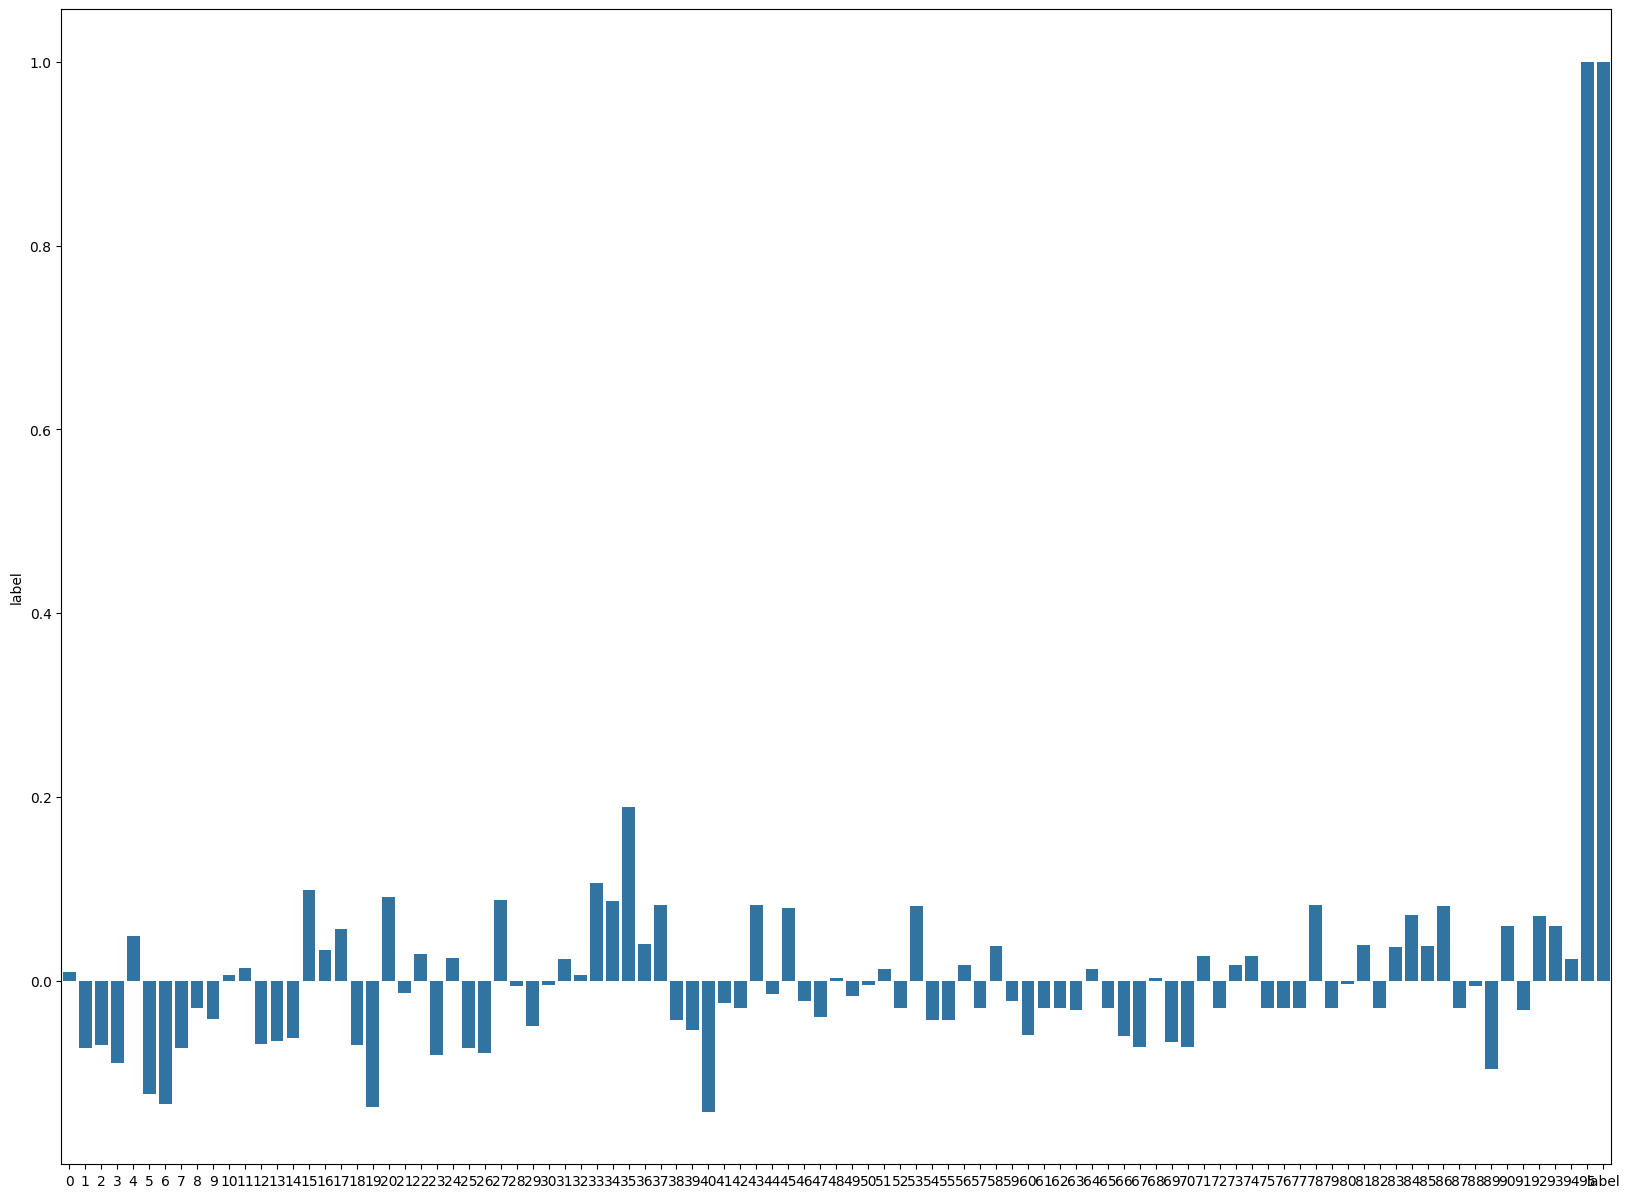

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.DataFrame(data.x.numpy())
df['label'] = data.y.numpy()
co_matrix=df.corr()['label']
plt.figure(figsize=(20,15))
sns.barplot(co_matrix);
# sns.heatmap(co_matrix, square=True, cbar_kws={"shrink": .5})

In [8]:
y = data.y

In [5]:
facebook = data

In [6]:
(facebook.y[facebook.edge_index].sum(0) == 0).sum(), (facebook.y[facebook.edge_index].sum(0) == 1).sum(), (facebook.y[facebook.edge_index].sum(0) == 2).sum()

(tensor(13736), tensor(5870), tensor(2039))

In [9]:
(torch.vstack((y[facebook.edge_index[0]], y[facebook.edge_index[1]])).sum(axis=0) == 0).sum() + (torch.vstack((y[facebook.edge_index[0]], y[facebook.edge_index[1]])).sum(axis=0) == 2).sum(), (torch.vstack((y[facebook.edge_index[0]], y[facebook.edge_index[1]])).sum(axis=0) == 1).sum()

(tensor(15775), tensor(5870))

In [11]:
all_possible_males = ((y == 0).sum()**2)/2
all_possible_females = ((y == 1).sum()**2)/2
all_possible_male_female = ((y == 0).sum() * (y == 1).sum()) / 2

all_possible_males = ((y == 0).sum()**2)/2
all_possible_females = ((y == 1).sum()**2)/2
all_possible_male_female = ((y == 0).sum() * (y == 1).sum()) / 2

print("Num edges in each group - Num nodes in the group")
print("MM", (y[facebook.edge_index].sum(0) == 0).sum(), '-', (y == 0).sum())
print("MF", (y[facebook.edge_index].sum(0) == 1).sum())
print("FF", (y[facebook.edge_index].sum(0) == 2).sum(), '-', (y == 1).sum())

print("Prob. of an edge in each group")
print("MM", (y[facebook.edge_index].sum(0) == 0).sum() / all_possible_males)
print("MF", (y[facebook.edge_index].sum(0) == 1).sum() / all_possible_male_female)
print("FF", (y[facebook.edge_index].sum(0) == 2).sum() / all_possible_females)

Num edges in each group - Num nodes in the group
MM tensor(13736) - tensor(296)
MF tensor(5870)
FF tensor(2039) - tensor(107)
Prob. of an edge in each group
MM tensor(0.3136)
MF tensor(0.3707)
FF tensor(0.3562)


In [10]:
(y[facebook.edge_index].sum(0) == 1).sum() / ((y[facebook.edge_index].sum(0) == 2).sum() + (y[facebook.edge_index].sum(0) == 0).sum())

tensor(0.3721)

### BUDDY

In [16]:
dataset, splits, directed, eval_metric = torch.load("/home/jrm28/fairness/subgraph_sketching-original/dataset/splits/gplus.pt")

for set in ['train', 'valid', 'test']:
    print(f"(BUDDY Sampling) Num pos-pairs in {set} set by group")
    print("MM", (dataset.y[splits[set].edge_label_index[:, splits[set].edge_label.bool()]].sum(0) == 0).sum())
    print("FF", (dataset.y[splits[set].edge_label_index[:, splits[set].edge_label.bool()]].sum(0) == 2).sum())
    print("MF", (dataset.y[splits[set].edge_label_index[:, splits[set].edge_label.bool()]].sum(0) == 1).sum())
    print(f"(BUDDY Sampling) Num neg-pairs {set} by group")
    print("MM", (dataset.y[splits[set].edge_label_index[:, ~splits[set].edge_label.bool()]].sum(0) == 0).sum())
    print("FF", (dataset.y[splits[set].edge_label_index[:, ~splits[set].edge_label.bool()]].sum(0) == 2).sum())
    print("MF", (dataset.y[splits[set].edge_label_index[:, ~splits[set].edge_label.bool()]].sum(0) == 1).sum())
    print("------------")

(BUDDY Sampling) Num pos-pairs in train set by group
MM tensor(79820)
FF tensor(1825)
MF tensor(24592)
(BUDDY Sampling) Num neg-pairs train by group
MM tensor(81714)
FF tensor(1574)
MF tensor(22949)
------------
(BUDDY Sampling) Num pos-pairs in valid set by group
MM tensor(11374)
FF tensor(261)
MF tensor(3541)
(BUDDY Sampling) Num neg-pairs valid by group
MM tensor(11671)
FF tensor(223)
MF tensor(3282)
------------
(BUDDY Sampling) Num pos-pairs in test set by group
MM tensor(22843)
FF tensor(522)
MF tensor(6988)
(BUDDY Sampling) Num neg-pairs test by group
MM tensor(23297)
FF tensor(466)
MF tensor(6590)
------------


### NCNC Splits

In [14]:
data, splits = torch.load("/home/jrm28/fairness/NeuralCommonNeighbor/dataset/splits/gplus.pt")
for set in ['train', 'valid', 'test']:
    print(f"(NCNC Sampling) Num pos-pairs in {set} set by group")
    print("MM", (data.y[splits[set]['edge']].sum(1) == 0).sum())
    print("FF", (data.y[splits[set]['edge']].sum(1) == 2).sum())
    print("MF", (data.y[splits[set]['edge']].sum(1) == 1).sum())
    print(f"(NCNC Sampling) Num neg-pairs in {set} set by group")
    print("MM", (data.y[splits[set]['edge_neg']].sum(1) == 0).sum())
    print("FF", (data.y[splits[set]['edge_neg']].sum(1) == 2).sum())
    print("MF", (data.y[splits[set]['edge_neg']].sum(1) == 1).sum())
    print("------------")

(NCNC Sampling) Num pos-pairs in train set by group
MM tensor(79842)
FF tensor(1813)
MF tensor(24582)
(NCNC Sampling) Num neg-pairs in train set by group
MM tensor(139847)
FF tensor(2850)
MF tensor(39423)
------------
(NCNC Sampling) Num pos-pairs in valid set by group
MM tensor(11392)
FF tensor(251)
MF tensor(3533)
(NCNC Sampling) Num neg-pairs in valid set by group
MM tensor(23297)
FF tensor(440)
MF tensor(6616)
------------
(NCNC Sampling) Num pos-pairs in test set by group
MM tensor(22803)
FF tensor(544)
MF tensor(7006)
(NCNC Sampling) Num neg-pairs in test set by group
MM tensor(23228)
FF tensor(433)
MF tensor(6692)
------------


#### Full-training

In [20]:
dataset, splits, directed, eval_metric = torch.load('full_training_gplus.pt')

for set in ['train', 'valid', 'test']:
    print(f"(Full Training Sampling) Num pos-pairs in {set} set by group")
    print("MM", (dataset.y[splits[set].edge_label_index[:, splits[set].edge_label.bool()]].sum(0) == 0).sum())
    print("FF", (dataset.y[splits[set].edge_label_index[:, splits[set].edge_label.bool()]].sum(0) == 2).sum())
    print("MF", (dataset.y[splits[set].edge_label_index[:, splits[set].edge_label.bool()]].sum(0) == 1).sum())
    print(f"(Full Training Sampling) Num neg-pairs {set} by group")
    print("MM", (dataset.y[splits[set].edge_label_index[:, ~splits[set].edge_label.bool()]].sum(0) == 0).sum())
    print("FF", (dataset.y[splits[set].edge_label_index[:, ~splits[set].edge_label.bool()]].sum(0) == 2).sum())
    print("MF", (dataset.y[splits[set].edge_label_index[:, ~splits[set].edge_label.bool()]].sum(0) == 1).sum())
    print("------------")

(Full Training Sampling) Num pos-pairs in train set by group
MM tensor(193812)
FF tensor(4462)
MF tensor(59730)
(Full Training Sampling) Num neg-pairs train by group
MM tensor(1000515)
FF tensor(19714)
MF tensor(281355)
------------
(Full Training Sampling) Num pos-pairs in valid set by group
MM tensor(5741)
FF tensor(122)
MF tensor(1725)
(Full Training Sampling) Num neg-pairs valid by group
MM tensor(994774)
FF tensor(19592)
MF tensor(279630)
------------
(Full Training Sampling) Num pos-pairs in test set by group
MM tensor(11390)
FF tensor(255)
MF tensor(3531)
(Full Training Sampling) Num neg-pairs test by group
MM tensor(983384)
FF tensor(19337)
MF tensor(276099)
------------


In [14]:
data, splits = torch.load("/home/jrm28/fairness/graphair/fairgraph/method/checkpoint/out/AUGMENTED_facebook_10000_epochs_2024-03-13_12-12-50/splits.pt", map_location=torch.device('cpu'))

In [18]:
data.edge_index.nonzero().shape

torch.Size([177522, 2])

In [3]:
data = torch.load("/home/jrm28/fairness/data/graphs/facebook.pt")

In [7]:
splits = torch.load("/home/jrm28/fairness/data/edge_splits/facebook_ncnc.pt")

In [8]:
splits['train']['edge']

tensor([[   0,    6],
        [   0,   61],
        [   0,   92],
        ...,
        [1034, 1043],
        [1035, 1044],
        [1037, 1039]])

In [11]:
print((data.y[splits['train']['edge']].sum(1) == 0).sum())
print((data.y[splits['train']['edge']].sum(1) == 1).sum())
print((data.y[splits['train']['edge']].sum(1) == 2).sum())

tensor(8257)
tensor(7928)
tensor(2541)
